In [1]:
import os
import sys
import anndata as ad
import numpy as np

import pandas as pd
import seaborn as sb
import metacells as mc

nb_dir = os.path.dirname(os.path.abspath("__file__"))  
project_root = os.path.abspath(os.path.join(nb_dir, "..", ".."))
sys.path.append(os.path.join(project_root, "utils"))

import constants
import utils

import tqdm 
import time

from statsmodels.stats.multitest import multipletests

from scipy.stats import wilcoxon, ks_2samp
from scipy.stats import chi2


%load_ext autoreload
%autoreload 2

sb.set_context("talk")
rng = np.random.default_rng(seed=42)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.cm as cm



import multiprocessing as mp
from functools import partial
import tqdm

2026-06-08 14:39:20.311511: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-08 14:39:20.332831: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
os.makedirs("./output", exist_ok=True)

In [3]:
data_path = os.path.join(project_root, "data", "differentiation_rate_data")

In [4]:
target_umis = 2**10
cells_ad = ad.read_h5ad(constants.CELLS_PATH)
cells_ad = mc.ut.slice(cells_ad, obs=cells_ad.obs.total_umis >= target_umis)

metacells_ad = ad.read_h5ad(constants.METACELLS_PATH)
cell_type_colors = pd.read_csv(constants.CELLS_TYPE_COLORS, index_col=0).to_dict()['color']

cells_with_clones_info = mc.ut.slice(cells_ad, obs=(cells_ad.obs.clone_id.notna()) & (cells_ad.obs.clone_id != "nan"))

clone_counts = cells_with_clones_info.obs['clone_exp_id'].value_counts()
valid_clone_ids = clone_counts[clone_counts > 1].index

cells_with_clones = cells_with_clones_info[cells_with_clones_info.obs['clone_exp_id'].isin(valid_clone_ids)]

trajectory_pc_mapper = utils.load_pickle(constants.TRAJECTORY_PC_MAPPER)
gene_modules_dict = utils.load_pickle(constants.GENE_MODULES_DICT_PATH)

/home/ofirr/miniforge3/envs/amosbase8/lib/python3.12/site-packages/rpy2/robjects/packages_utils.py:127: UserWarning: Conflict when converting R symbols in the package "princurve" to Python symbols: 
-lines_principal_curve -> lines.principal_curve, lines.principal.curve
- plot_principal_curve -> plot.principal_curve, plot.principal.curve
- points_principal_curve -> points.principal_curve, points.principal.curve
  warn(msg)


In [5]:
def plot_pseudotime_heatmap(
    pseudotime_df, synthetic_df,
    n_bins=200, figsize=(10, 0.3),
    row_window=None,       
    red_alpha=None,      
    fontsize=30,
    n_rows_multipler=0.1,
    otuput_path = "",
    filename = "",
):
    required_cols = {"min_pseudotime", "median_pseudotime", "max_pseudotime"}
    for name, df in [("pseudotime_df", pseudotime_df), ("synthetic_df", synthetic_df)]:
        missing = required_cols - set(df.columns)
        if missing:
            raise ValueError(f"{name} missing columns: {sorted(missing)}")
    if not pseudotime_df.index.equals(synthetic_df.index):
        raise ValueError("pseudotime_df and synthetic_df must have the SAME index and order.")

    idx = pseudotime_df.index
    n_rows = len(idx)

    def smooth_bands(df):
        df = df.copy()
        cols = ["min_pseudotime", "median_pseudotime", "max_pseudotime"]
        if row_window and row_window >= 2:
            win = int(row_window)
            sm = df[cols].rolling(window=win, center=True, min_periods=1).mean()
        else:
            sm = df[cols]

        # clip to [0,1], then enforce ordering per row (min<=median<=max)
        arr = sm.to_numpy(dtype=float)
        arr = np.clip(arr, 0.0, 1.0)
        arr_sorted = np.sort(arr, axis=1)  # sorts columns per row ascending
        # Re-map: 0->min, 1->median, 2->max
        out = pd.DataFrame(arr_sorted, index=df.index, columns=cols)
        return out

    p_smooth = smooth_bands(pseudotime_df)
    s_smooth = smooth_bands(synthetic_df)

    cols_lin = np.linspace(0, 1, n_bins)

    img = np.ones((n_rows, n_bins, 3), dtype=float)

    gray  = np.array([0.8, 0.8, 0.8])
    red   = np.array([1.0, 0.0, 0.0])
    black = np.array([0.0, 0.0, 0.0])

    def val_to_idx(v):
        return int(np.clip(np.round(v * (n_bins - 1)), 0, n_bins - 1))

    def range_to_slice(vmin, vmax):
        if np.isnan(vmin) or np.isnan(vmax):
            return slice(0, 0)
        a = int(np.clip(np.floor(vmin * (n_bins - 1)), 0, n_bins - 1))
        b = int(np.clip(np.ceil (vmax * (n_bins - 1)), 0, n_bins - 1))
        if b < a:
            a, b = b, a
        return slice(a, b + 1)

    for r, key in enumerate(idx):
        pmin = p_smooth.at[key, "min_pseudotime"]
        pmax = p_smooth.at[key, "max_pseudotime"]
        pmed = p_smooth.at[key, "median_pseudotime"]

        smin = s_smooth.at[key, "min_pseudotime"]
        smax = s_smooth.at[key, "max_pseudotime"]

        pslice = range_to_slice(pmin, pmax)
        if pslice.stop - pslice.start > 0:
            img[r, pslice, :] = gray

        sslice = range_to_slice(smin, smax)
        if sslice.stop - sslice.start > 0:
            if red_alpha is None:
                # solid red (original behavior)
                img[r, sslice, :] = red
            else:
                a = float(np.clip(red_alpha, 0.0, 1.0))
                img[r, sslice, :] = (1 - a) * img[r, sslice, :] + a * red

        if not np.isnan(pmed):
            mcol = val_to_idx(pmed)
            img[r, mcol, :] = black

    fig, ax = plt.subplots(figsize=(figsize[0], max(figsize[1], n_rows * n_rows_multipler)))
    ax.imshow(img, aspect='auto', origin='upper', extent=[0, 1, n_rows, 0])
    ax.set_xlabel("Pseudotime", fontsize=fontsize)
    ax.set_ylabel("")

    ax.set_yticks([])
    ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
    ax.set_xticklabels([f"{x:.2f}" for x in [0.0, 0.25, 0.5, 0.75, 1.0]], fontsize=fontsize)
    ax.set_xlim(0, 1)

    # Legend
    gray_patch  = mpatches.Patch(facecolor=gray,  label='Inside pseudotime range')
    red_vis     = (1 - (red_alpha or 1.0)) * np.ones(3) + (red_alpha or 1.0) * red
    red_patch   = mpatches.Patch(facecolor=red_vis, label='Inside synthetic range')
    black_patch = mpatches.Patch(facecolor=black, label='Median pseudotime')
    white_patch = mpatches.Patch(facecolor='white', edgecolor='black', label='Outside pseudotime range')
    ax.legend(handles=[white_patch, gray_patch, red_patch, black_patch],
              loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2, frameon=False).remove()
    plt.tight_layout()
    
    if otuput_path and filename:
        plt.savefig(f"{otuput_path}/{filename}.pdf", dpi=1200, bbox_inches='tight')
        plt.show()
        plt.close()
    else:
        plt.show()

def get_clones_stats_info(trajectory_cells_with_clones_ad):
    # Recreate trajectory_cells_df
    trajectory_cells_df = trajectory_cells_with_clones_ad.obs[["sample_day_as_int", "clone_exp_id", "pseudotime"]]
    trajectory_cells_df["pseudotime"] = trajectory_cells_df["pseudotime"].values

    # Grouped object
    grouped = trajectory_cells_df.groupby(["clone_exp_id", "sample_day_as_int"])

    # Compute aggregated stats excluding MAD
    clone_day_stats = (
        grouped
        .agg(
            n_cells=("pseudotime", "count"),
            
            mean_pseudotime=("pseudotime", "mean"),
            median_pseudotime=("pseudotime", "median"),
            max_pseudotime=("pseudotime", "max"),
            min_pseudotime=("pseudotime", "min"),
            std_pseudotime=("pseudotime", "std"),
            
        )
        .reset_index()
    )

    # Compute MAD separately and merge
    mad_series = grouped["pseudotime"].apply(lambda x: np.mean(np.abs(x - x.mean()))).rename("mad_pseudotime")
    clone_day_stats = clone_day_stats.merge(mad_series, on=["clone_exp_id", "sample_day_as_int"])

    # Compute delta
    clone_day_stats["delta_pseudotime"] = (
        clone_day_stats["max_pseudotime"] - clone_day_stats["min_pseudotime"]
    )

    # Get the first timepoint
    first_day = clone_day_stats["sample_day_as_int"].min()

    # Subset just that day's stats
    first_day_df = clone_day_stats[clone_day_stats["sample_day_as_int"] == first_day].copy()

    # Sort by min_interp_time and delta
    first_day_df = first_day_df.sort_values(
    by=["mean_pseudotime", "delta_pseudotime"],
    ascending=[True, False]
    )

    # Get clone order
    clone_order = first_day_df["clone_exp_id"].tolist()

    
    return trajectory_cells_df, clone_day_stats, clone_order


def plot_clone_day_stats(
    clone_day_stats,
    clone_order,
    output_folder=None,
    clone_to_show=None,
    lines=None,
    filename = "",
    heatmap_width=0.5,
    plot_width=5,
    FONT_SIZE=25,
    plot_height_per_clone=0.08,
):
    # defaults
    if clone_to_show is None:
        clone_to_show = []
    if lines is None:
        lines = []

    # --- Global range for pseudotime and n_cells ---
    global_max_pseudotime = 1.1
    global_min_pseudotime = float(clone_day_stats["min_pseudotime"].min())

    # --- log2 scale for clone size normalization ---
    cds = clone_day_stats.copy()
    cds["n_cells_log2"] = cds["n_cells"].replace(0, 1).apply(np.log2)
    min_log2 = float(cds["n_cells_log2"].min())
    max_log2 = float(cds["n_cells_log2"].max())
    log2_norm = mcolors.Normalize(vmin=min_log2, vmax=max_log2)
    cmap = cm.get_cmap("YlGnBu")

    # --- Main pseudotime bars + heatmaps ---
    for i, day in enumerate(sorted(cds["sample_day_as_int"].unique())):
        df = cds[cds["sample_day_as_int"] == day].copy()
        df["clone_exp_id"] = pd.Categorical(df["clone_exp_id"], categories=clone_order, ordered=True)
        df = df.sort_values("clone_exp_id").reset_index(drop=True)
        n_rows = len(df)

        # fate heatmap only on first figure if requested
        fig_width = plot_width + heatmap_width 
        fig_height = max(n_rows * plot_height_per_clone, 6)
        fig = plt.figure(figsize=(fig_width, fig_height))

        gs = fig.add_gridspec(1, 2, width_ratios=[heatmap_width, plot_width], wspace=0)
        ax_bar  = fig.add_subplot(gs[1])
        ax_heat = fig.add_subplot(gs[0], sharey=ax_bar)

        # --- SIZE heatmap ---
        heat_data = df["n_cells_log2"].values.reshape(-1, 1)
        ax_heat.imshow(
            heat_data,
            aspect="auto",
            cmap=cmap,
            norm=log2_norm,
            origin="lower",
            extent=[0, 1, -0.5, n_rows - 0.5],  # y aligned with bar rows
        )
        ax_heat.set_xticks([])
        ax_heat.set_yticks([])

        # --- Pseudotime bars ---
        for j, row in df.iterrows():
            color = "red" if (clone_to_show and row["clone_exp_id"] in clone_to_show) else "gray"
            ax_bar.plot([row["min_pseudotime"], row["max_pseudotime"]], [j, j], marker=".", color=color)
            ax_bar.plot([row["median_pseudotime"], row["median_pseudotime"]], [j, j],
                        marker=".", color="black", markersize=7)

        ax_bar.set_ylim(-0.5, n_rows - 0.5)  # exact match to heatmap extent
        if lines:
            ax_bar.axvline(x=lines[0], color="black", linestyle="--", linewidth=1)
            ax_bar.axvline(x=lines[1], color="black", linestyle="--", linewidth=1)
        ax_bar.set_xlim(global_min_pseudotime, global_max_pseudotime)
        ax_bar.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
        ax_bar.set_yticks([])
        ax_bar.set_xlabel("Pseudotime", fontsize=FONT_SIZE)
        ax_bar.tick_params(axis="x", labelsize=FONT_SIZE)
        ax_bar.tick_params(axis="y", labelsize=FONT_SIZE)

        plt.tight_layout()
        if output_folder:
            plt.savefig(f"{output_folder}/{filename}_{day}.pdf", dpi=1200, bbox_inches='tight')
            plt.show()
            plt.close()
        else:
            plt.show()

    # --- Standalone colorbar for log2(clone size) ---
    fig, ax = plt.subplots(figsize=(0.5, 4))
    sm = cm.ScalarMappable(cmap=cmap, norm=log2_norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=ax)
    cbar.set_label("log2(clone size)", fontsize=FONT_SIZE)
    cbar.ax.tick_params(labelsize=FONT_SIZE)
    plt.tight_layout()
    if output_folder:
        plt.savefig(f"{output_folder}/{filename}_legend.pdf", dpi=1200, bbox_inches='tight')
        plt.show()
        plt.close()
    else:
        plt.show()


# ----------------------------
# WRAPPED FUNCTION FOR 1 RUN
# ----------------------------
def run_single_synthetic(
    run_id, trajectory_cells_df, ds_cells_df,
    clone_day_stats, target_umis, trajectory_genes_modules, pc,
):
    synthetic_cells_per_clone_per_day_pseudotime = {}

    for day in trajectory_cells_df.sample_day_as_int.unique():
        synthetic_cells_per_clone = get_samples_cells_no_replacement(
            day, clone_day_stats, trajectory_cells_df, ds_cells_df, target_umis
        )
        synthetic_cells_per_clone_per_day_pseudotime[day] = {}

        for clone_id, synthetic_df in synthetic_cells_per_clone.items():
            # Normalize by UMIs
            fp = synthetic_df / target_umis

            # Gene module activity matrix
            trajectory_modules_df = pd.DataFrame(0, index=synthetic_df.index, columns=trajectory_genes_modules.keys())
            for module, genes in trajectory_genes_modules.items():
                expression = fp.loc[:, genes].sum(axis=1)
                trajectory_modules_df[module] = expression

            pseudotime = pc.predict(trajectory_modules_df).sort_index()
            synthetic_cells_per_clone_per_day_pseudotime[day][clone_id] = pseudotime

    # Collate all pseudotime values
    l = []
    for day, clones_dict in synthetic_cells_per_clone_per_day_pseudotime.items():
        for clone, pseudotime in clones_dict.items():
            l.append(pd.DataFrame({
                "sample_day_as_int": day,
                "clone_exp_id": clone,
                "pseudotime": pseudotime
            }))
    synthetic_trajectory_cells_df = pd.concat(l)
    
    synthetic_trajectory_cells_df["cell_id"] = synthetic_trajectory_cells_df.index
    synthetic_trajectory_cells_df["distance_from_median"] = (
        synthetic_trajectory_cells_df["pseudotime"] -
        synthetic_trajectory_cells_df.groupby(["clone_exp_id", "sample_day_as_int"])["pseudotime"].transform("median")
    )   
    
    grouped = synthetic_trajectory_cells_df.groupby(["clone_exp_id", "sample_day_as_int"], observed=False)
    stats_df = grouped.agg(
        n_cells=("pseudotime", "count"),
        mean_pseudotime=("pseudotime", "mean"),
        median_pseudotime=("pseudotime", "median"),
        max_pseudotime=("pseudotime", "max"),
        min_pseudotime=("pseudotime", "min"),
        std_pseudotime=("pseudotime", "std"),
    ).reset_index()

    # Add MAD
    stats_df = stats_df.merge(grouped["pseudotime"].apply(lambda x: np.mean(np.abs(x - x.mean()))).rename("mad_pseudotime"), on=["clone_exp_id", "sample_day_as_int"])

    # Add delta
    stats_df["delta_pseudotime"] = stats_df["max_pseudotime"] - stats_df["min_pseudotime"]
    stats_df["run_id"] = run_id

    return stats_df , synthetic_trajectory_cells_df


def get_samples_cells_no_replacement(day, clone_day_stats, trajectory_cells_df, ds_cells_df, target_umis):
    umis_sum_per_clone = ds_cells_df.loc[trajectory_cells_df[trajectory_cells_df.sample_day_as_int == day].index].groupby(
        [trajectory_cells_df[trajectory_cells_df.sample_day_as_int == day].clone_exp_id], observed=True
        ).sum()

    umis_sum_per_clone = umis_sum_per_clone.astype(int)  # ensure int counts

    n_umis_per_cell = target_umis  # UMIs per synthetic cell

    synthetic_cells_per_clone = {}

    for clone_id, pseudobulk in umis_sum_per_clone.iterrows(): # tqdm.tqdm(umis_sum_per_clone.iterrows(), total=len(umis_sum_per_clone)):
        total_umis = pseudobulk.sum()
        if total_umis == 0:
            continue

        # Get number of synthetic cells to generate for this clone/day
        n_cells = clone_day_stats[(clone_day_stats['clone_exp_id'] == clone_id) & 
                                  (clone_day_stats['sample_day_as_int'] == day)]['n_cells'].values[0]

        # Flatten pseudobulk into list of gene labels, repeated by counts
        genes = pseudobulk.index.values
        counts = pseudobulk.values

        umi_pool = np.repeat(genes, counts)
        
        if len(umi_pool) < n_cells * n_umis_per_cell:
            # Not enough UMIs to sample without replacement for all synthetic cells
            # Option 1: skip, Option 2: reduce number of synthetic cells, Option 3: sample partial
            # Here we reduce the number of cells accordingly
            max_cells = len(umi_pool) // n_umis_per_cell
            if max_cells == 0:
                continue
            n_cells = min(n_cells, max_cells)

        # Shuffle the UMIs (in place)
        np.random.shuffle(umi_pool)

        # Split UMIs into synthetic cells
        synthetic_cells = []
        for i in range(n_cells):
            start = i * n_umis_per_cell
            end = start + n_umis_per_cell
            cell_umis = umi_pool[start:end]

            # Count UMIs per gene for this synthetic cell
            unique, counts_cell = np.unique(cell_umis, return_counts=True)
            cell_counts = pd.Series(0, index=genes)
            cell_counts.loc[unique] = counts_cell
            synthetic_cells.append(cell_counts)

        synthetic_df = pd.DataFrame(synthetic_cells).fillna(0).astype(int)
        synthetic_cells_per_clone[clone_id] = synthetic_df

    return synthetic_cells_per_clone

In [6]:
utils.plot_generic_dict_of_colors({
    "Median pseudotime": "black",
    "Observed min/max pseudotime range": "gray",
    "Synthetic min/max pseudotime range": "red"
}, output_path=os.path.join("./output", "4D_legend.pdf"), ncol=1)

## Figure 4C

In [7]:
trajectory = "Ery"
trajectory_genes_modules =  {i+"_score_sum": gene_modules_dict[i] for i in gene_modules_dict if "ery" in i}

trajectory_cells_with_clones_ad = mc.ut.slice(cells_with_clones, obs=cells_with_clones.obs.top_level_cell_type.isin(constants.TRAJECTORIES_TO_TOP_LEVEL_CELL_TYPE_DICT[trajectory]))

# filter only cells with at least two timepoints and at least 2 cells per timepoint
min_cells_per_timepoint = 2
min_timepoints = 2

n_cells_per_clone_per_day = trajectory_cells_with_clones_ad.obs.groupby(["clone_exp_id","sample_day_as_int"]).size().unstack().fillna(0).astype(int) 
clones_with_enough_data = n_cells_per_clone_per_day.index[np.sum(n_cells_per_clone_per_day >= min_cells_per_timepoint, axis=1) >= min_timepoints]
trajectory_cells_with_clones_ad = mc.ut.slice(trajectory_cells_with_clones_ad, obs=trajectory_cells_with_clones_ad.obs.clone_exp_id.isin(clones_with_enough_data))
trajectory_metacells_ad = mc.ut.slice(metacells_ad, obs=metacells_ad.obs.type.isin(constants.TRAJECTORIES_TO_TOP_LEVEL_CELL_TYPE_DICT[trajectory]))
mc.ut.set_o_data(trajectory_metacells_ad, "type", pd.Categorical(trajectory_metacells_ad.obs.type, categories=[i for i in cell_type_colors if i in trajectory_metacells_ad.obs.type.unique()], ordered=True))

mc.ut.set_o_data(trajectory_cells_with_clones_ad, "pseudotime", trajectory_cells_with_clones_ad.obs["%s_pseudotime" %trajectory].values)
trajectory_cells_with_clones_ad.obs.groupby(["condition"]).clone_exp_id.nunique().sort_values()

trajectory_metacells_ad = mc.ut.slice(metacells_ad, obs=metacells_ad.obs.type.isin(constants.TRAJECTORIES_TO_TOP_LEVEL_CELL_TYPE_DICT[trajectory]))
trajectory_cells = mc.ut.slice(cells_with_clones, obs=cells_with_clones.obs.cell_type.isin(constants.TRAJECTORIES_TO_TOP_LEVEL_CELL_TYPE_DICT[trajectory]))

pc = trajectory_pc_mapper[trajectory]

orig_trajectory_cells_with_clones_ad = trajectory_cells_with_clones_ad.copy()

/tmp/ipykernel_1013018/1553988140.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  n_cells_per_clone_per_day = trajectory_cells_with_clones_ad.obs.groupby(["clone_exp_id","sample_day_as_int"]).size().unstack().fillna(0).astype(int)
set unnamed.obs[type]: 91 objects
set unnamed.obs[pseudotime]: 18106 float64s
/tmp/ipykernel_1013018/1553988140.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trajectory_cells_with_clones_ad.obs.groupby(["condition"]).clone_exp_id.nunique().sort_values()


In [8]:
condition = "I"
trajectory_cells_with_clones_ad = mc.ut.slice(trajectory_cells_with_clones_ad, obs=trajectory_cells_with_clones_ad.obs.condition == condition)
trajectory_cells_with_clones_ad_orig = trajectory_cells_with_clones_ad.copy()

trajectory_cells_with_clones_ad = mc.ut.slice(trajectory_cells_with_clones_ad, obs=trajectory_cells_with_clones_ad.obs.exp_id == 1)

n_cells_per_clone_per_day = trajectory_cells_with_clones_ad.obs.groupby(["clone_exp_id","sample_day_as_int"]).size().unstack().fillna(0) 

clones_with_enough_data = n_cells_per_clone_per_day.index[np.all(n_cells_per_clone_per_day >= min_cells_per_timepoint,axis=1)]
trajectory_cells_with_clones_ad = mc.ut.slice(trajectory_cells_with_clones_ad, obs=trajectory_cells_with_clones_ad.obs.clone_exp_id.isin(clones_with_enough_data))

/tmp/ipykernel_1013018/446538285.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  n_cells_per_clone_per_day = trajectory_cells_with_clones_ad.obs.groupby(["clone_exp_id","sample_day_as_int"]).size().unstack().fillna(0)


In [9]:
# Recreate trajectory_cells_df
trajectory_cells_df = trajectory_cells_with_clones_ad.obs[["sample_day_as_int", "clone_exp_id", "pseudotime"]]

# Grouped object
grouped = trajectory_cells_df.groupby(["clone_exp_id", "sample_day_as_int"])

# Compute aggregated stats excluding MAD
clone_day_stats = (
    grouped
    .agg(
        n_cells=("pseudotime", "count"),
        mean_pseudotime=("pseudotime", "mean"),
        median_pseudotime=("pseudotime", "median"),
        max_pseudotime=("pseudotime", "max"),
        min_pseudotime=("pseudotime", "min"),
        std_pseudotime=("pseudotime", "std"),
    )
    .reset_index()
)

# Compute MAD separately and merge
mad_series = grouped["pseudotime"].apply(lambda x: np.mean(np.abs(x - x.mean()))).rename("mad_pseudotime")
clone_day_stats = clone_day_stats.merge(mad_series, on=["clone_exp_id", "sample_day_as_int"])

# Compute delta
clone_day_stats["delta_pseudotime"] = (
    clone_day_stats["max_pseudotime"] - clone_day_stats["min_pseudotime"]
)

# Get the first timepoint
first_day = clone_day_stats["sample_day_as_int"].min()

# Subset just that day's stats
first_day_df = clone_day_stats[clone_day_stats["sample_day_as_int"] == first_day].copy()

# Sort by min_pseudotime and delta
first_day_df = first_day_df.sort_values(
    by=["mean_pseudotime", "delta_pseudotime"],
    ascending=[True, False]
)

# Get clone order
clone_order = first_day_df["clone_exp_id"].tolist()

/tmp/ipykernel_1013018/3690431219.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = trajectory_cells_df.groupby(["clone_exp_id", "sample_day_as_int"])


In [10]:
trajectory_cells_df, clone_day_stats, clone_order = get_clones_stats_info(trajectory_cells_with_clones_ad)

/tmp/ipykernel_1013018/3191914831.py:117: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trajectory_cells_df["pseudotime"] = trajectory_cells_df["pseudotime"].values
/tmp/ipykernel_1013018/3191914831.py:120: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = trajectory_cells_df.groupby(["clone_exp_id", "sample_day_as_int"])


In [11]:
use_saved_data = True

In [12]:
if use_saved_data:
    synthetic_run_dfs = utils.load_pickle(os.path.join(data_path, "main_synthetic_run_dfs.pkl"))
    synthetic_runs_cells_df = utils.load_pickle(os.path.join(data_path, "main_synthetic_runs_cells_df.pkl"))

else:
    n_runs = 1000
    args_list = list(range(n_runs))
    
    ds_cells_df = mc.ut.get_vo_frame(trajectory_cells_with_clones_ad, "downsampled")

    wrapped_func = partial(
        run_single_synthetic,
        trajectory_cells_df=trajectory_cells_df,
        ds_cells_df=ds_cells_df,
        clone_day_stats=clone_day_stats,
        target_umis=target_umis,
        trajectory_genes_modules=trajectory_genes_modules,
        pc=pc,
    )

    # Parallel execution
    results = utils.run_multiprocess(wrapped_func, args_list, num_workers=100, thread_pool=False)
    synthetic_run_dfs = [result[0] for result in results]
    synthetic_runs_cells_df = [result[1] for result in results]

In [13]:
if not use_saved_data:
    utils.save_to_pickle(synthetic_run_dfs, os.path.join(data_path, "main_synthetic_run_dfs.pkl"))
    utils.save_to_pickle(synthetic_runs_cells_df, os.path.join(data_path, "main_synthetic_runs_cells_df.pkl"))

In [14]:
all_runs_df = pd.concat(synthetic_run_dfs)

# Median across runs per (clone, day)
synthetic_median_stats = (
    all_runs_df
    .groupby(["clone_exp_id", "sample_day_as_int"])
    .median()
    .reset_index()
)

/tmp/ipykernel_1013018/3191914831.py:194: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("YlGnBu")


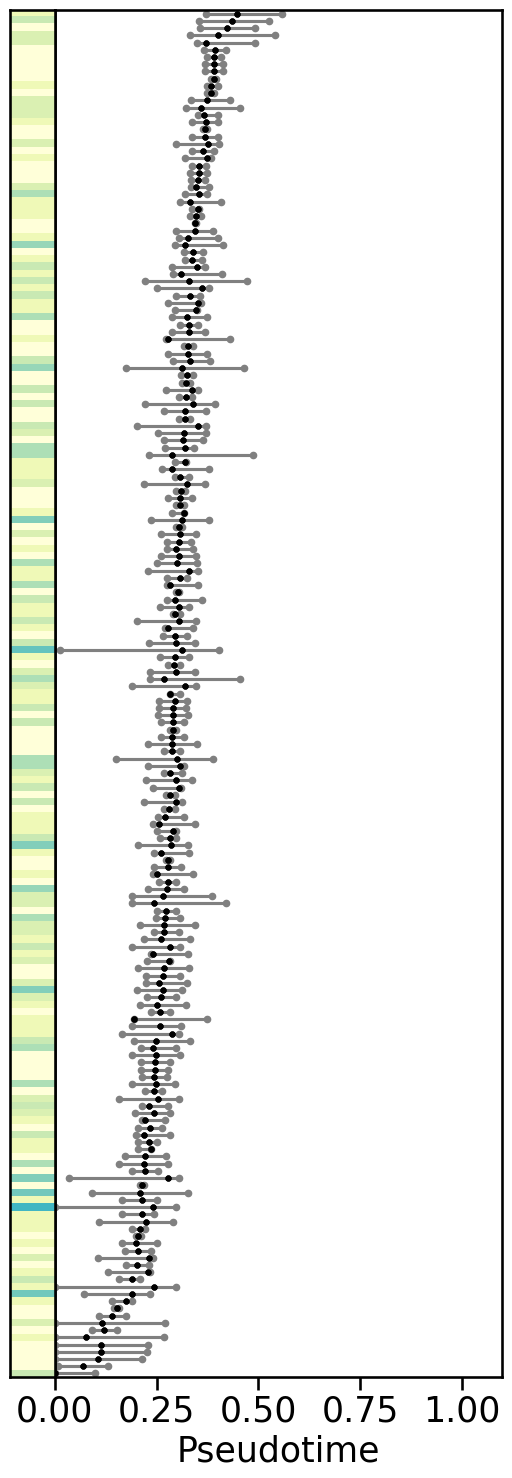

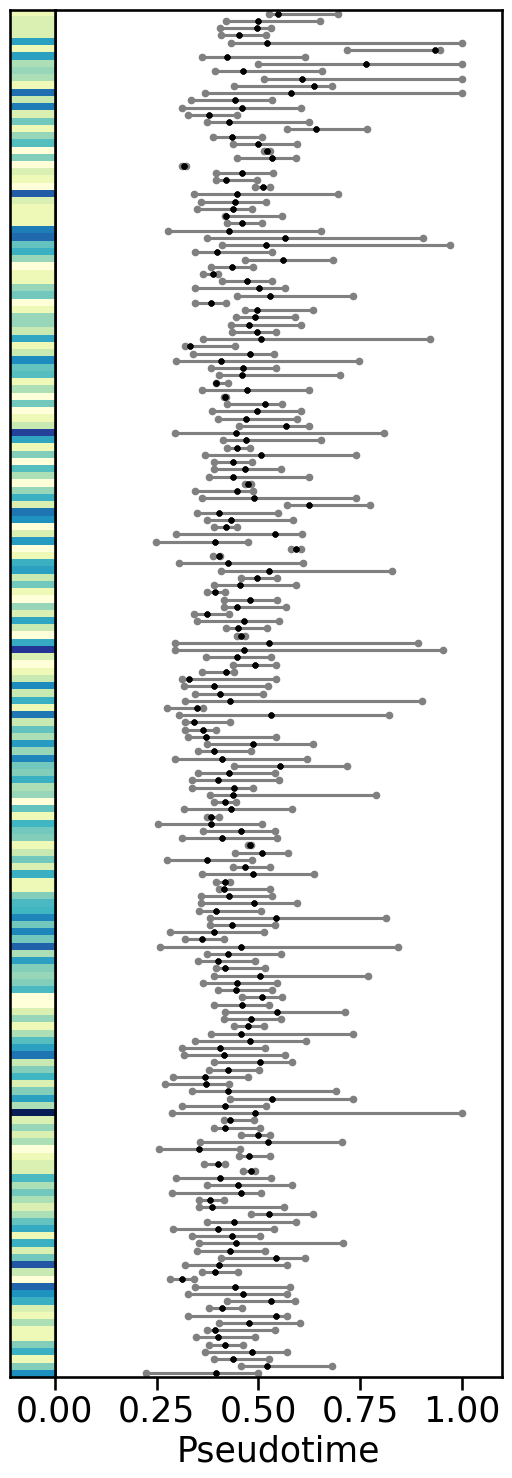

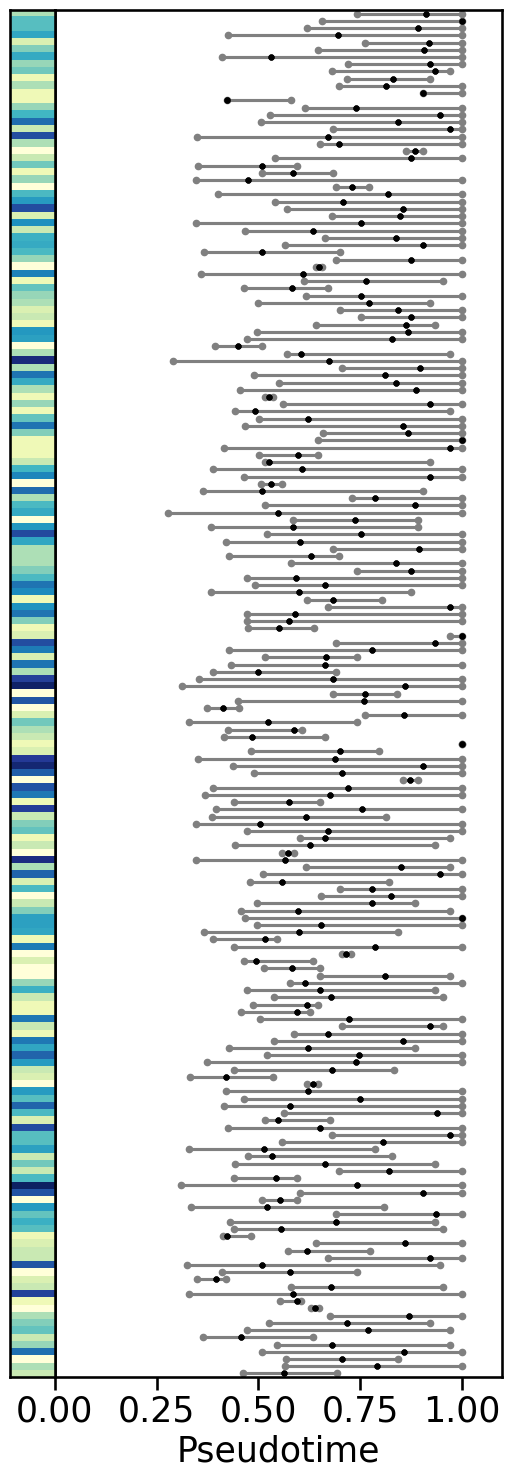

/tmp/ipykernel_1013018/3191914831.py:258: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


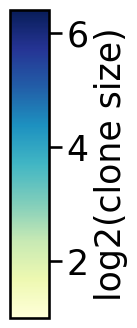

In [15]:
plot_clone_day_stats(clone_day_stats, clone_order, output_folder="./output", filename="4C")

/tmp/ipykernel_1013018/3191914831.py:194: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("YlGnBu")


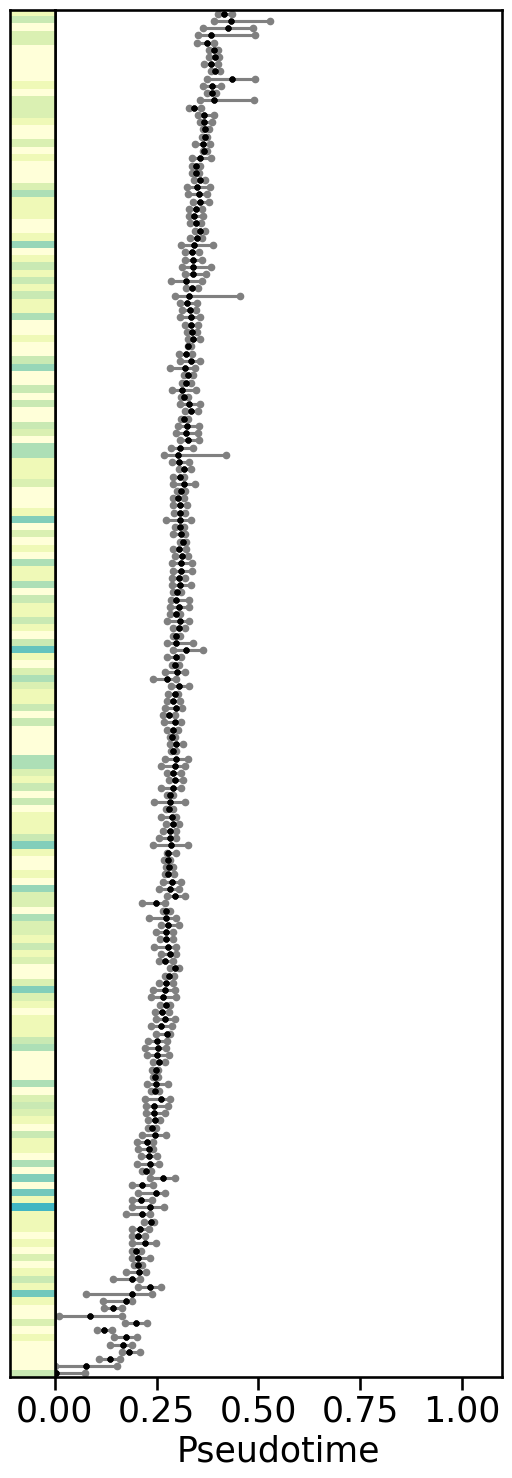

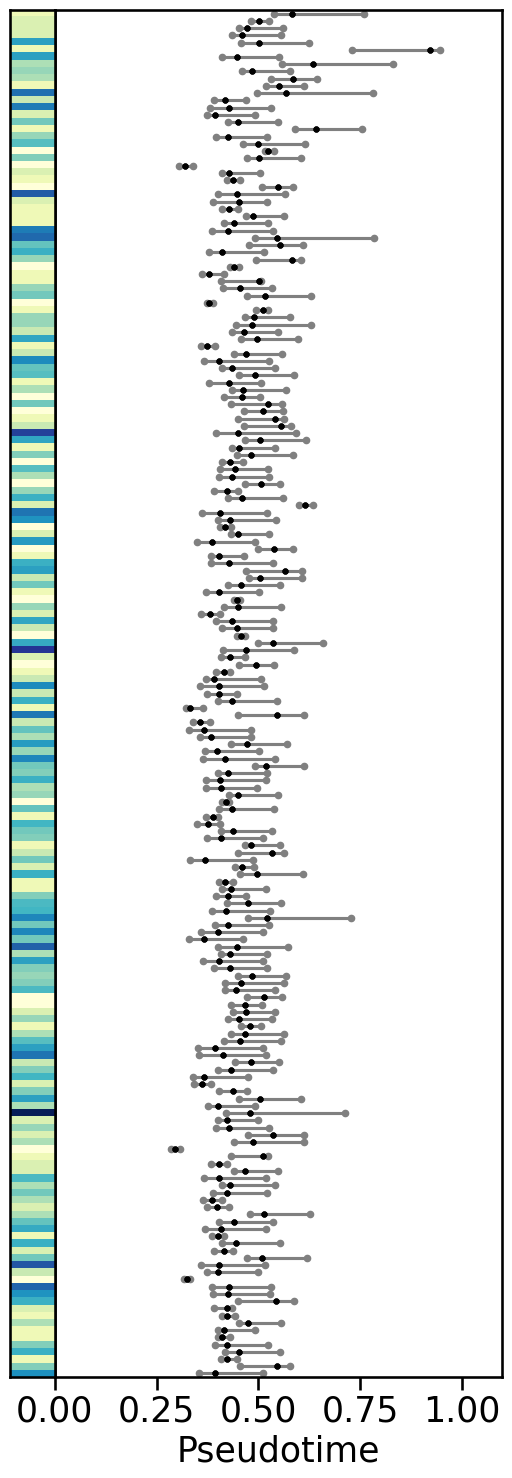

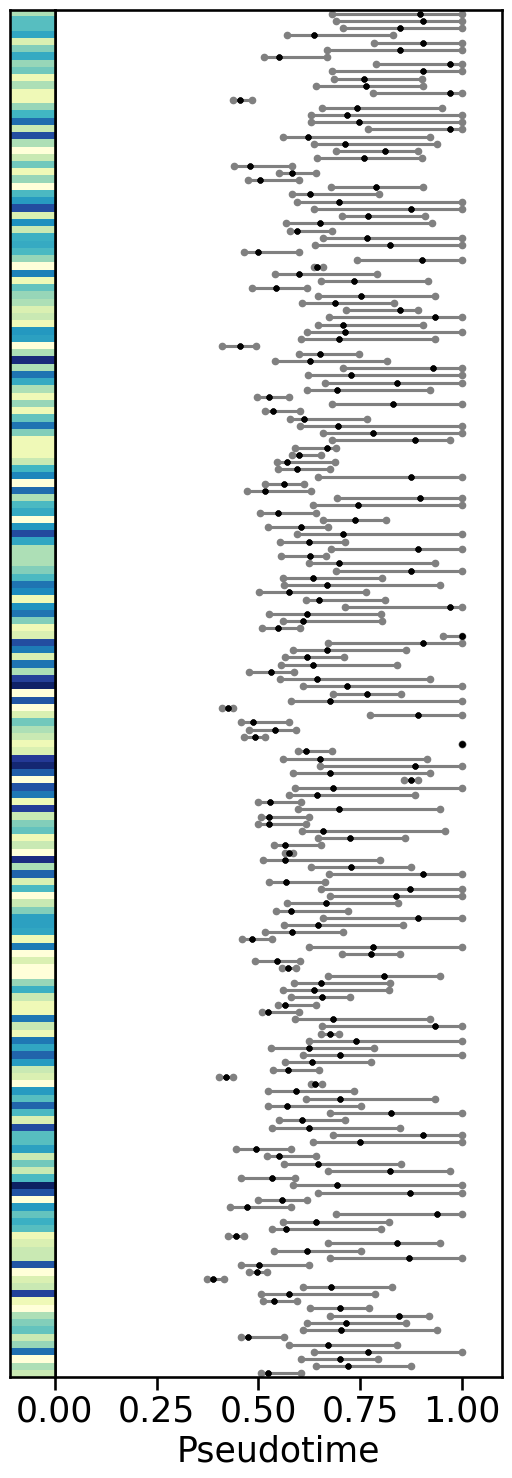

/tmp/ipykernel_1013018/3191914831.py:258: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


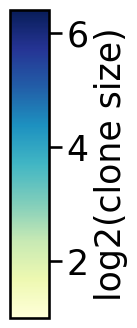

In [16]:
plot_clone_day_stats(synthetic_median_stats, clone_order)

In [17]:
print(f"Number of clones: %d" % len(trajectory_cells_df.clone_exp_id.unique()))

Number of clones: 189


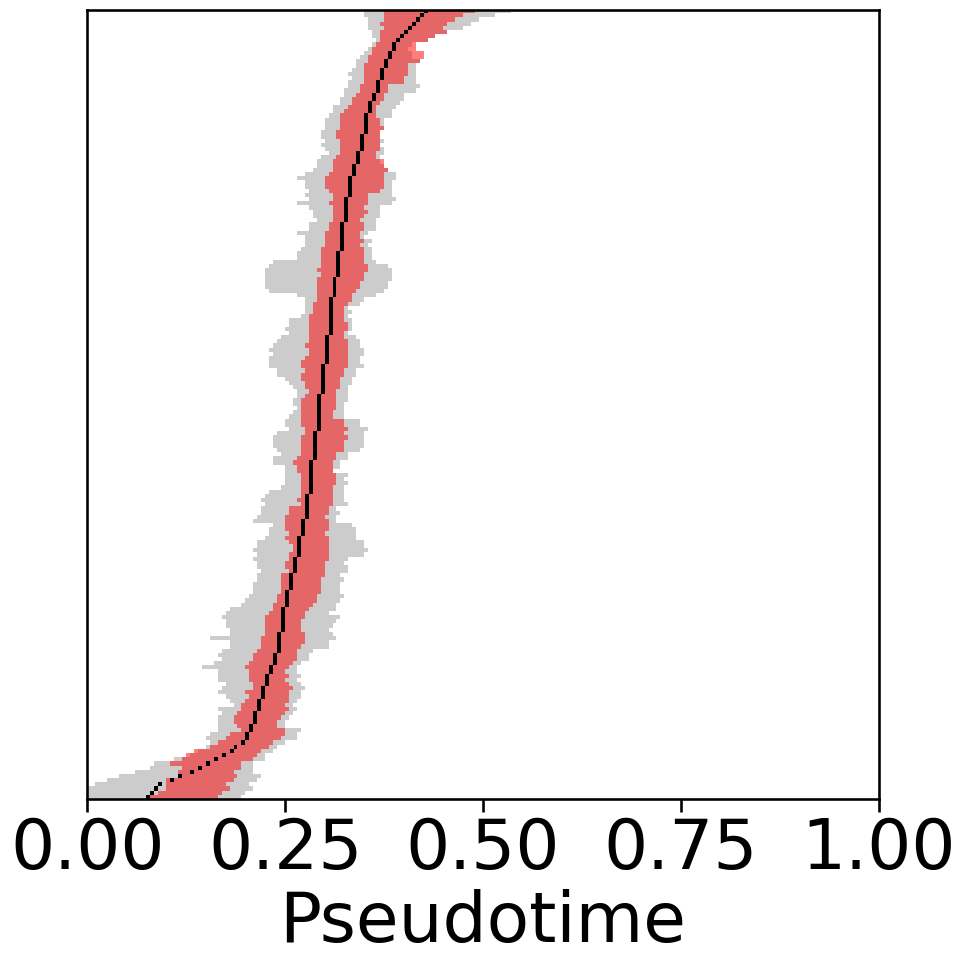

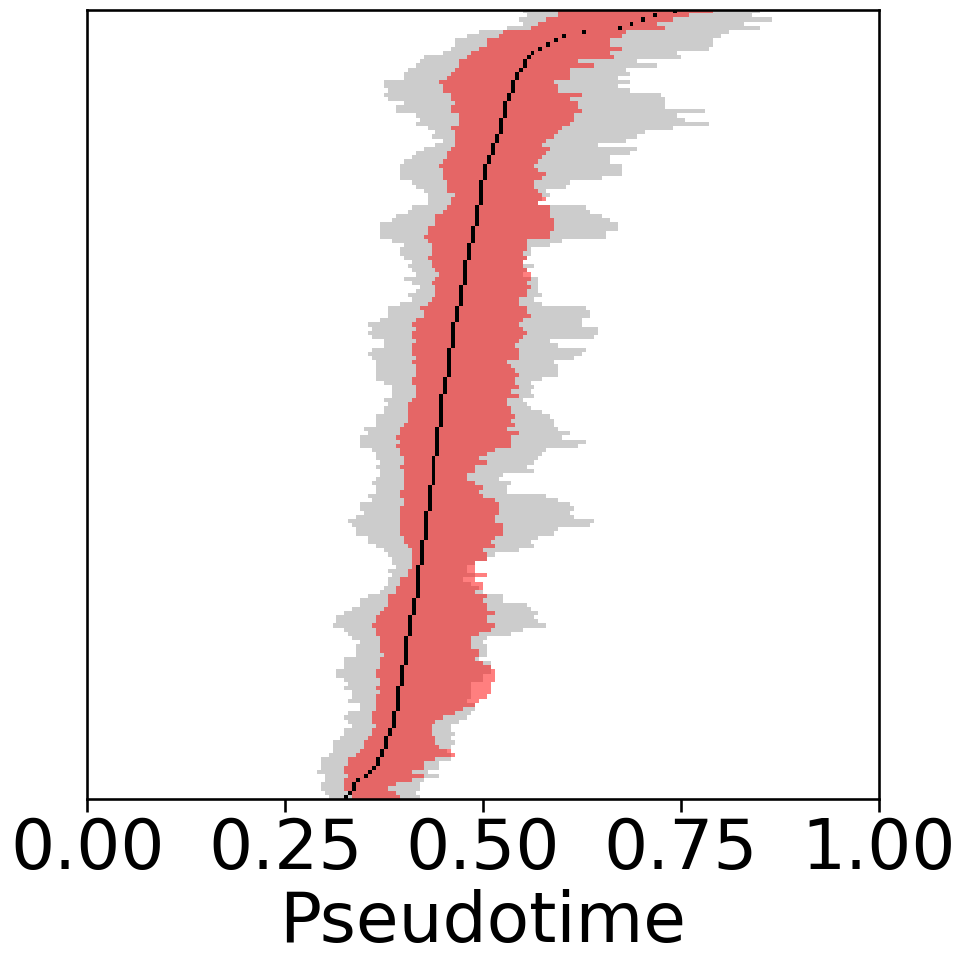

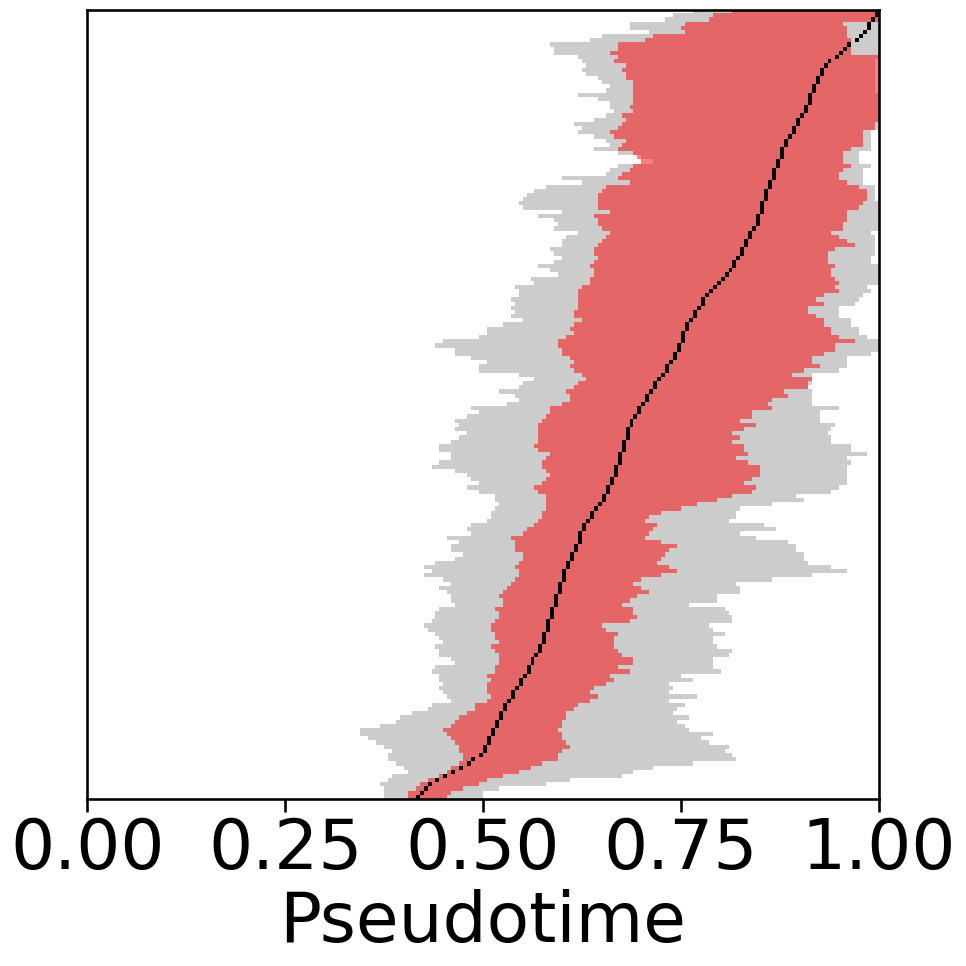

In [18]:
for day in [3, 7, 10]:
    pseudotime_df = clone_day_stats[clone_day_stats["sample_day_as_int"] == day].copy()
    clone_order = clone_day_stats[clone_day_stats["sample_day_as_int"] == day].sort_values("median_pseudotime").clone_exp_id.tolist()
    pseudotime_df.clone_exp_id = pd.Categorical(pseudotime_df.clone_exp_id, categories=clone_order, ordered=True)
    pseudotime_df = pseudotime_df.sort_values("clone_exp_id").reset_index(drop=True)
    synthetic_df = synthetic_median_stats[synthetic_median_stats.sample_day_as_int == day].copy()
    synthetic_df.clone_exp_id = pd.Categorical(synthetic_df.clone_exp_id, categories=clone_order, ordered=True)
    synthetic_df = synthetic_df.sort_values("clone_exp_id").reset_index(drop=True)

    plot_pseudotime_heatmap(pseudotime_df.sort_index(ascending=False), synthetic_df.sort_index(ascending=False), 
                            n_bins=200, figsize=(10, 10), row_window=8, red_alpha=0.5, fontsize=50, n_rows_multipler=0.01,
                            otuput_path="./output", filename=f"4D_day{day}")

In [19]:
for day in clone_day_stats.sample_day_as_int.unique():
    kstet_res = ks_2samp(
            synthetic_median_stats[synthetic_median_stats.sample_day_as_int == day].delta_pseudotime,
            clone_day_stats[clone_day_stats.sample_day_as_int == day].delta_pseudotime
        )
    print(f"Day {day}: KS test statistic={kstet_res.statistic}, p-value={kstet_res.pvalue}")

Day 3: KS test statistic=0.4656084656084656, p-value=7.13168933704772e-19
Day 7: KS test statistic=0.47619047619047616, p-value=9.286772169900464e-20
Day 10: KS test statistic=0.47619047619047616, p-value=9.286772169900464e-20


In [20]:
ery_clone_day_stats_l =[]

In [21]:
synthetic_all = pd.concat(synthetic_run_dfs, ignore_index=True)

# compute empirical p-values
pvals = []
for _, row in clone_day_stats.iterrows():
    cid, day, real_val = row["clone_exp_id"], row["sample_day_as_int"], row["delta_pseudotime"]
    subset = synthetic_all[(synthetic_all["clone_exp_id"] == cid) &
                           (synthetic_all["sample_day_as_int"] == day)]
    if len(subset) == 0:
        pvals.append(np.nan)
        continue
    p = (1 + (subset["delta_pseudotime"] >= real_val).sum()) / (1 + len(subset))
    pvals.append(p)

clone_day_stats["pval"] = pvals
ery_clone_day_stats_l.append(clone_day_stats)

In [22]:
# multiple testing correction (Benjamini-Hochberg FDR)
mask = clone_day_stats["pval"].notna()
clone_day_stats.loc[mask, "fdr"] = multipletests(clone_day_stats.loc[mask, "pval"], method="fdr_bh")[1]

# how many significant
sig = (clone_day_stats["fdr"] < 0.05).sum()

print(f"Significant clones+timepoints: {sig} / {mask.sum()}")


sig = (clone_day_stats.groupby("clone_exp_id")["fdr"].min() < 0.05).sum()
print(f"Significant clones: {sig} / {len(clone_day_stats.clone_exp_id.unique())}")

Significant clones+timepoints: 291 / 567
Significant clones: 167 / 189


/tmp/ipykernel_1013018/2134164213.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sig = (clone_day_stats.groupby("clone_exp_id")["fdr"].min() < 0.05).sum()


## Figure S4E-F

In [23]:
# Because we move to multiple experiments and have multiple days in them, we will work with day rank - first, second, etc sample day

In [24]:
trajectory = "Ery"
trajectory_genes_modules =  {i+"_score_sum": gene_modules_dict[i] for i in gene_modules_dict if "ery" in i}

trajectory_cells_with_clones_ad = mc.ut.slice(cells_with_clones, obs=cells_with_clones.obs.top_level_cell_type.isin(constants.TRAJECTORIES_TO_TOP_LEVEL_CELL_TYPE_DICT[trajectory]))

# filter only cells with at least two timepoints and at least 2 cells per timepoint
min_cells_per_timepoint = 2
min_timepoints = 2

n_cells_per_clone_per_day = trajectory_cells_with_clones_ad.obs.groupby(["clone_exp_id","sample_day_as_int"]).size().unstack().fillna(0).astype(int) 
clones_with_enough_data = n_cells_per_clone_per_day.index[np.sum(n_cells_per_clone_per_day >= min_cells_per_timepoint, axis=1) >= min_timepoints]
trajectory_cells_with_clones_ad = mc.ut.slice(trajectory_cells_with_clones_ad, obs=trajectory_cells_with_clones_ad.obs.clone_exp_id.isin(clones_with_enough_data))
trajectory_metacells_ad = mc.ut.slice(metacells_ad, obs=metacells_ad.obs.type.isin(constants.TRAJECTORIES_TO_TOP_LEVEL_CELL_TYPE_DICT[trajectory]))
mc.ut.set_o_data(trajectory_metacells_ad, "type", pd.Categorical(trajectory_metacells_ad.obs.type, categories=[i for i in cell_type_colors if i in trajectory_metacells_ad.obs.type.unique()], ordered=True))

mc.ut.set_o_data(trajectory_cells_with_clones_ad, "pseudotime", trajectory_cells_with_clones_ad.obs["%s_pseudotime" %trajectory].values)
trajectory_cells_with_clones_ad.obs.groupby(["condition"]).clone_exp_id.nunique().sort_values()

trajectory_metacells_ad = mc.ut.slice(metacells_ad, obs=metacells_ad.obs.type.isin(constants.TRAJECTORIES_TO_TOP_LEVEL_CELL_TYPE_DICT[trajectory]))
trajectory_cells = mc.ut.slice(cells_with_clones, obs=cells_with_clones.obs.cell_type.isin(constants.TRAJECTORIES_TO_TOP_LEVEL_CELL_TYPE_DICT[trajectory]))

pc = trajectory_pc_mapper[trajectory]

orig_trajectory_cells_with_clones_ad = trajectory_cells_with_clones_ad.copy()

/tmp/ipykernel_1013018/1553988140.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  n_cells_per_clone_per_day = trajectory_cells_with_clones_ad.obs.groupby(["clone_exp_id","sample_day_as_int"]).size().unstack().fillna(0).astype(int)
set unnamed.obs[type]: 91 objects
set unnamed.obs[pseudotime]: 18106 float64s
/tmp/ipykernel_1013018/1553988140.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trajectory_cells_with_clones_ad.obs.groupby(["condition"]).clone_exp_id.nunique().sort_values()


In [25]:
condition = "I"
trajectory_cells_with_clones_ad = mc.ut.slice(trajectory_cells_with_clones_ad, obs=trajectory_cells_with_clones_ad.obs.condition == condition)
trajectory_cells_with_clones_ad = mc.ut.slice(trajectory_cells_with_clones_ad, obs=trajectory_cells_with_clones_ad.obs.exp_id != 1)

mc.ut.set_o_data(trajectory_cells_with_clones_ad, "sample_day_rank", trajectory_cells_with_clones_ad.obs.groupby("exp_id")["sample_day_as_int"].rank(method="dense").astype(int))

exp_day = trajectory_cells_with_clones_ad.obs.sample_day_rank.unique()

n_cells_per_clone_per_day = trajectory_cells_with_clones_ad.obs.groupby(["clone_exp_id","sample_day_rank"]).size().unstack().fillna(0) 

clones_with_enough_data = n_cells_per_clone_per_day.index[np.sum(n_cells_per_clone_per_day >= min_cells_per_timepoint, axis=1) == len(exp_day)]
trajectory_cells_with_clones_ad = mc.ut.slice(trajectory_cells_with_clones_ad, obs=trajectory_cells_with_clones_ad.obs.clone_exp_id.isin(clones_with_enough_data))

/tmp/ipykernel_1013018/1670048818.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mc.ut.set_o_data(trajectory_cells_with_clones_ad, "sample_day_rank", trajectory_cells_with_clones_ad.obs.groupby("exp_id")["sample_day_as_int"].rank(method="dense").astype(int))
set unnamed.obs[sample_day_rank]: 4364 int64s
/tmp/ipykernel_1013018/1670048818.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  n_cells_per_clone_per_day = trajectory_cells_with_clones_ad.obs.groupby(["clone_exp_id","sample_day_rank"]).size().unstack().fillna(0)


In [26]:
trajectory_cells_df, clone_day_stats, clone_order = get_clones_stats_info(trajectory_cells_with_clones_ad)

# Recreate trajectory_cells_df
trajectory_cells_df = trajectory_cells_with_clones_ad.obs[["sample_day_rank", "clone_exp_id", "pseudotime"]]

# Grouped object
grouped = trajectory_cells_df.groupby(["clone_exp_id", "sample_day_rank"])

# Compute aggregated stats excluding MAD
clone_day_stats = (
    grouped
    .agg(
        n_cells=("pseudotime", "count"),
        mean_pseudotime=("pseudotime", "mean"),
        median_pseudotime=("pseudotime", "median"),
        max_pseudotime=("pseudotime", "max"),
        min_pseudotime=("pseudotime", "min"),
        std_pseudotime=("pseudotime", "std"),
    )
    .reset_index()
)

# Compute MAD separately and merge
mad_series = grouped["pseudotime"].apply(lambda x: np.mean(np.abs(x - x.mean()))).rename("mad_pseudotime")
clone_day_stats = clone_day_stats.merge(mad_series, on=["clone_exp_id", "sample_day_rank"])

clone_day_stats["sample_day_as_int"] = clone_day_stats["sample_day_rank"]

# Compute delta
clone_day_stats["delta_pseudotime"] = (
    clone_day_stats["max_pseudotime"] - clone_day_stats["min_pseudotime"]
)

# Get the first timepoint
first_day = clone_day_stats["sample_day_rank"].min()

# Subset just that day's stats
first_day_df = clone_day_stats[clone_day_stats["sample_day_rank"] == first_day].copy()

# Sort by min_pseudotime and delta
first_day_df = first_day_df.sort_values(
    by=["mean_pseudotime", "delta_pseudotime"],
    ascending=[True, False]
)

# Get clone order
clone_order = first_day_df["clone_exp_id"].tolist()

/tmp/ipykernel_1013018/3191914831.py:117: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trajectory_cells_df["pseudotime"] = trajectory_cells_df["pseudotime"].values
/tmp/ipykernel_1013018/3191914831.py:120: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = trajectory_cells_df.groupby(["clone_exp_id", "sample_day_as_int"])
/tmp/ipykernel_1013018/3229143171.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the

In [27]:
print(f"Number of clones: {len(clone_day_stats.clone_exp_id.unique())}")

Number of clones: 82


/tmp/ipykernel_1013018/3191914831.py:194: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("YlGnBu")


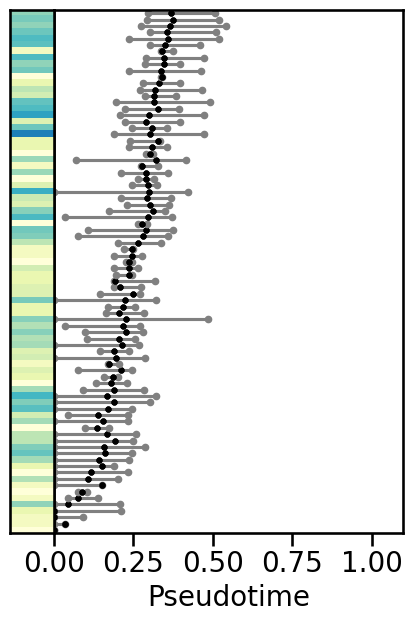

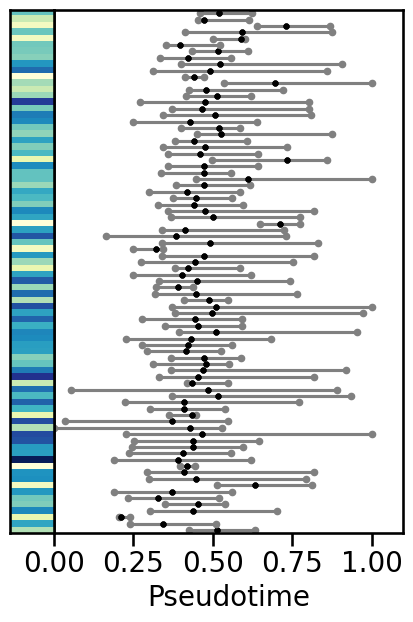

/tmp/ipykernel_1013018/3191914831.py:258: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


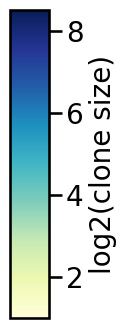

In [28]:
plot_clone_day_stats(clone_day_stats, clone_order, output_folder="./output", filename="S4E", plot_width=4, FONT_SIZE=20)

In [29]:
trajectory_cells_ad = cells_ad[trajectory_cells_df.index].copy()

trajectory_cells_df["sample_day_as_int"] = trajectory_cells_df["sample_day_rank"]
mc.ut.set_o_data(trajectory_cells_ad, "sample_day_as_int", trajectory_cells_df["sample_day_as_int"])

/tmp/ipykernel_1013018/3435372291.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trajectory_cells_df["sample_day_as_int"] = trajectory_cells_df["sample_day_rank"]


In [30]:
use_saved_data = True

In [31]:
if use_saved_data:
    synthetic_run_dfs = utils.load_pickle(os.path.join(data_path, "S4E_synthetic_run_dfs.pkl"))
    synthetic_runs_cells_df = utils.load_pickle(os.path.join(data_path, "S4E_synthetic_runs_cells_df.pkl"))

else:
    n_runs = 1000
    args_list = list(range(n_runs))
    
    ds_cells_df = mc.ut.get_vo_frame(trajectory_cells_with_clones_ad, "downsampled")

    wrapped_func = partial(
        run_single_synthetic,
        trajectory_cells_df=trajectory_cells_df,
        ds_cells_df=ds_cells_df,
        clone_day_stats=clone_day_stats,
        target_umis=target_umis,
        trajectory_genes_modules=trajectory_genes_modules,
        pc=pc,
    )

    # Parallel execution
    results = utils.run_multiprocess(wrapped_func, args_list, num_workers=100, thread_pool=False)
    synthetic_run_dfs = [result[0] for result in results]
    synthetic_runs_cells_df = [result[1] for result in results]

In [32]:
if not use_saved_data:
    utils.save_to_pickle(synthetic_run_dfs, os.path.join(data_path, "S4E_synthetic_run_dfs.pkl"))
    utils.save_to_pickle(synthetic_runs_cells_df, os.path.join(data_path, "S4E_synthetic_runs_cells_df.pkl"))

In [33]:
all_runs_df = pd.concat(synthetic_run_dfs)

# Median across runs per (clone, day)
synthetic_median_stats = (
    all_runs_df
    .groupby(["clone_exp_id", "sample_day_as_int"])
    .median()
    .reset_index()
)

/tmp/ipykernel_1013018/3191914831.py:194: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("YlGnBu")


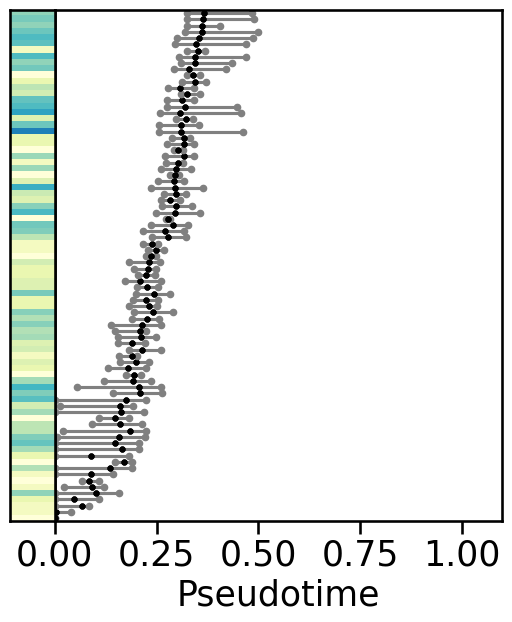

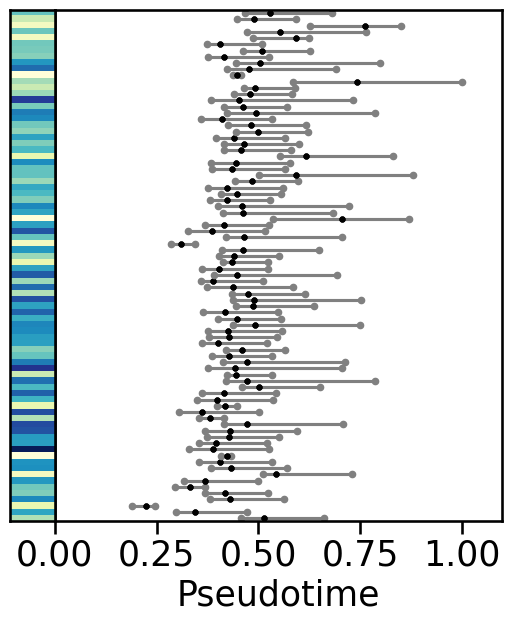

/tmp/ipykernel_1013018/3191914831.py:258: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


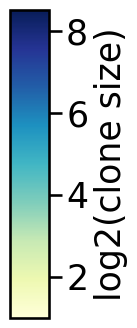

In [34]:
plot_clone_day_stats(synthetic_median_stats, clone_order)

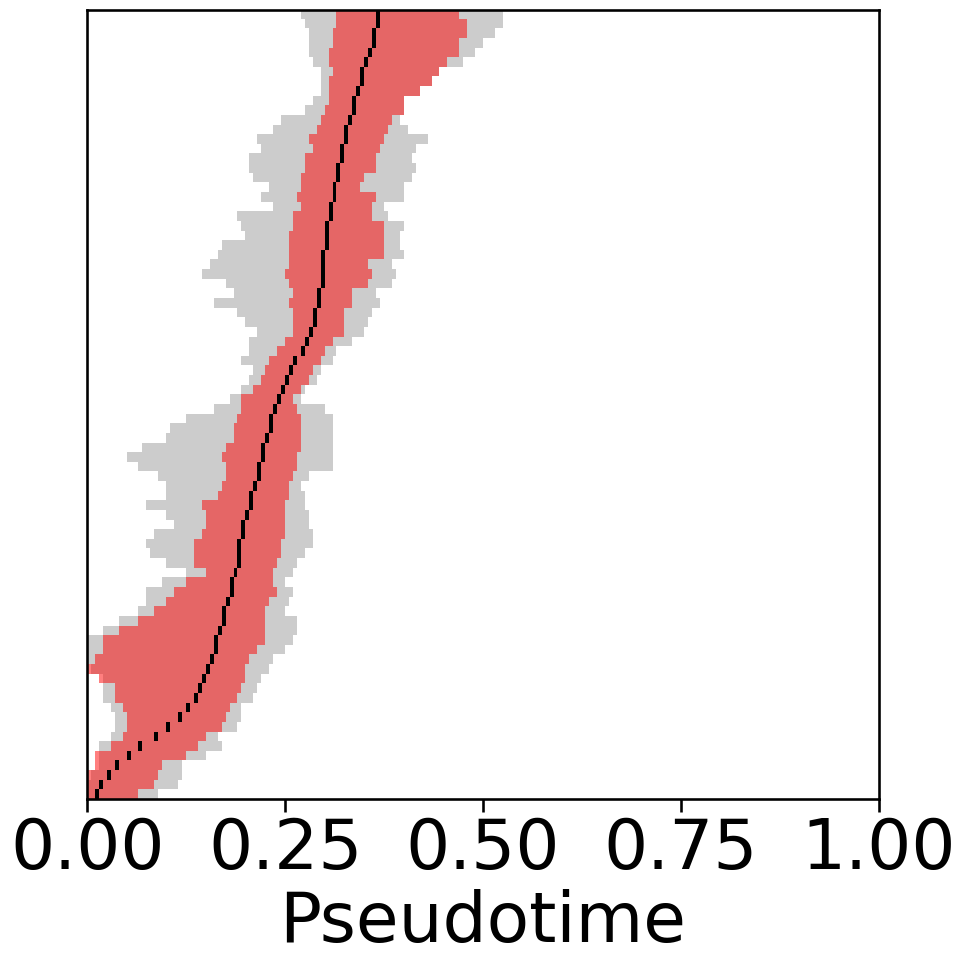

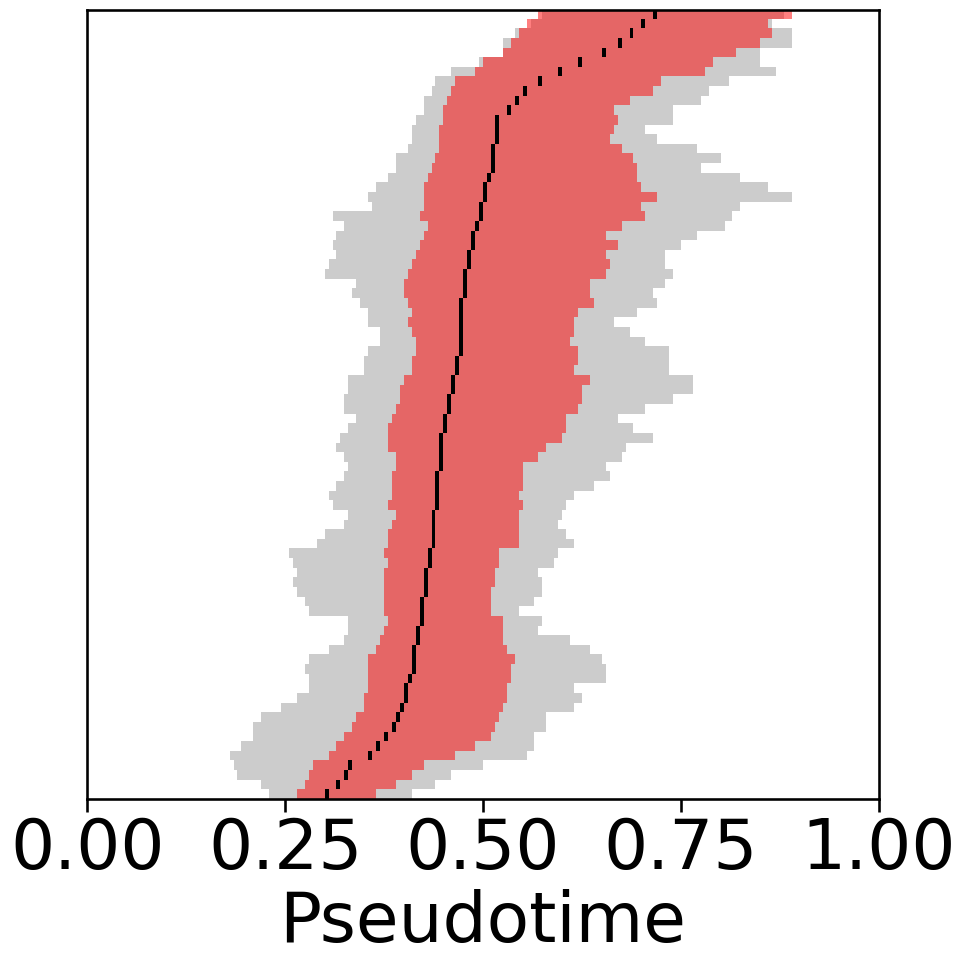

In [35]:
for day in clone_day_stats.sample_day_as_int.unique():
    pseudotime_df = clone_day_stats[clone_day_stats["sample_day_as_int"] == day].copy()
    clone_order = clone_day_stats[clone_day_stats["sample_day_as_int"] == day].sort_values("median_pseudotime").clone_exp_id.tolist()
    pseudotime_df.clone_exp_id = pd.Categorical(pseudotime_df.clone_exp_id, categories=clone_order, ordered=True)
    pseudotime_df = pseudotime_df.sort_values("clone_exp_id").reset_index(drop=True)
    # pseudotime_df = pseudotime_df.sort_values("mean_pseudotime").reset_index(drop=True)
    synthetic_df = synthetic_median_stats[synthetic_median_stats.sample_day_as_int == day].copy()
    synthetic_df.clone_exp_id = pd.Categorical(synthetic_df.clone_exp_id, categories=clone_order, ordered=True)
    synthetic_df = synthetic_df.sort_values("clone_exp_id").reset_index(drop=True)
    plot_pseudotime_heatmap(pseudotime_df.sort_index(ascending=False), synthetic_df.sort_index(ascending=False), n_bins=200, 
                            figsize=(10, 10), row_window=7, red_alpha=0.5, fontsize=50, n_rows_multipler=0.01,
                            otuput_path="./output", filename=f"S4F_day{day}")


In [36]:
for day in clone_day_stats.sample_day_as_int.unique():
    kstet_res = ks_2samp(
            synthetic_median_stats[synthetic_median_stats.sample_day_as_int == day].delta_pseudotime,
            clone_day_stats[clone_day_stats.sample_day_as_int == day].delta_pseudotime
        )
    print(f"Day {day}: KS test statistic={kstet_res.statistic}, p-value={kstet_res.pvalue}")

Day 1: KS test statistic=0.32926829268292684, p-value=0.000246534391793793
Day 2: KS test statistic=0.47560975609756095, p-value=9.241815513088363e-09


In [37]:
synthetic_all = pd.concat(synthetic_run_dfs, ignore_index=True)

# compute empirical p-values
pvals = []
for _, row in clone_day_stats.iterrows():
    cid, day, real_val = row["clone_exp_id"], row["sample_day_as_int"], row["delta_pseudotime"]
    subset = synthetic_all[(synthetic_all["clone_exp_id"] == cid) &
                           (synthetic_all["sample_day_as_int"] == day)]
    if len(subset) == 0:
        pvals.append(np.nan)
        continue
    p = (1 + (subset["delta_pseudotime"] >= real_val).sum()) / (1 + len(subset))
    pvals.append(p)

clone_day_stats["pval"] = pvals
ery_clone_day_stats_l.append(clone_day_stats)

In [38]:
# multiple testing correction (Benjamini-Hochberg FDR)
mask = clone_day_stats["pval"].notna()
clone_day_stats.loc[mask, "fdr"] = multipletests(clone_day_stats.loc[mask, "pval"], method="fdr_bh")[1]

# how many significant
sig = (clone_day_stats["fdr"] < 0.05).sum()

print(f"Significant clones+timepoints: {sig} / {mask.sum()}")


sig = (clone_day_stats.groupby("clone_exp_id")["fdr"].min() < 0.05).sum()
print(f"Significant clones: {sig} / {len(clone_day_stats.clone_exp_id.unique())}")

Significant clones+timepoints: 88 / 164
Significant clones: 66 / 82


/tmp/ipykernel_1013018/2134164213.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sig = (clone_day_stats.groupby("clone_exp_id")["fdr"].min() < 0.05).sum()


In [39]:
## and the real test - of all data combined

In [40]:
clone_day_stats_combined = pd.concat(ery_clone_day_stats_l)

In [41]:
# multiple testing correction (Benjamini-Hochberg FDR)
mask = clone_day_stats_combined["pval"].notna()
clone_day_stats_combined.loc[mask, "fdr"] = multipletests(clone_day_stats_combined.loc[mask, "pval"], method="fdr_bh")[1]

# how many significant
sig = (clone_day_stats_combined["fdr"] < 0.05).sum()

print(f"Significant clones+timepoints: {sig} / {mask.sum()}")


sig = (clone_day_stats_combined.groupby("clone_exp_id")["fdr"].min() < 0.05).sum()
print(f"Significant clones: {sig} / {len(clone_day_stats_combined.clone_exp_id.unique())}")

Significant clones+timepoints: 379 / 731
Significant clones: 233 / 271


## Figure S4E

In [42]:
# We are using only 2 timepoints sampling because 3 timepoints sampling has too few clones to have statistical power

In [43]:
trajectory = "Eosinophil"
trajectory_genes_modules =  {i+"_score_sum": gene_modules_dict[i] for i in gene_modules_dict if "eosinophil" in i}

trajectory_cells_with_clones_ad = mc.ut.slice(cells_with_clones, obs=cells_with_clones.obs.top_level_cell_type.isin(constants.TRAJECTORIES_TO_TOP_LEVEL_CELL_TYPE_DICT[trajectory]))

# filter only cells with at least two timepoints and at least 2 cells per timepoint
min_cells_per_timepoint = 2
min_timepoints = 2

n_cells_per_clone_per_day = trajectory_cells_with_clones_ad.obs.groupby(["clone_exp_id","sample_day_as_int"]).size().unstack().fillna(0).astype(int) 
clones_with_enough_data = n_cells_per_clone_per_day.index[np.sum(n_cells_per_clone_per_day >= min_cells_per_timepoint, axis=1) >= min_timepoints]
trajectory_cells_with_clones_ad = mc.ut.slice(trajectory_cells_with_clones_ad, obs=trajectory_cells_with_clones_ad.obs.clone_exp_id.isin(clones_with_enough_data))
trajectory_metacells_ad = mc.ut.slice(metacells_ad, obs=metacells_ad.obs.type.isin(constants.TRAJECTORIES_TO_TOP_LEVEL_CELL_TYPE_DICT[trajectory]))
mc.ut.set_o_data(trajectory_metacells_ad, "type", pd.Categorical(trajectory_metacells_ad.obs.type, categories=[i for i in cell_type_colors if i in trajectory_metacells_ad.obs.type.unique()], ordered=True))

mc.ut.set_o_data(trajectory_cells_with_clones_ad, "pseudotime", trajectory_cells_with_clones_ad.obs["%s_pseudotime" %trajectory].values)
trajectory_cells_with_clones_ad.obs.groupby(["condition"]).clone_exp_id.nunique().sort_values()

trajectory_metacells_ad = mc.ut.slice(metacells_ad, obs=metacells_ad.obs.type.isin(constants.TRAJECTORIES_TO_TOP_LEVEL_CELL_TYPE_DICT[trajectory]))
trajectory_cells = mc.ut.slice(cells_with_clones, obs=cells_with_clones.obs.cell_type.isin(constants.TRAJECTORIES_TO_TOP_LEVEL_CELL_TYPE_DICT[trajectory]))

pc = trajectory_pc_mapper[trajectory]

orig_trajectory_cells_with_clones_ad = trajectory_cells_with_clones_ad.copy()

/tmp/ipykernel_1013018/2820568304.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  n_cells_per_clone_per_day = trajectory_cells_with_clones_ad.obs.groupby(["clone_exp_id","sample_day_as_int"]).size().unstack().fillna(0).astype(int)
set unnamed.obs[type]: 197 objects
set unnamed.obs[pseudotime]: 3303 float64s
/tmp/ipykernel_1013018/2820568304.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trajectory_cells_with_clones_ad.obs.groupby(["condition"]).clone_exp_id.nunique().sort_values()


In [44]:
condition = "III"
trajectory_cells_with_clones_ad = mc.ut.slice(trajectory_cells_with_clones_ad, obs=trajectory_cells_with_clones_ad.obs.condition == condition)


mc.ut.set_o_data(trajectory_cells_with_clones_ad, "sample_day_rank", trajectory_cells_with_clones_ad.obs.groupby("exp_id")["sample_day_as_int"].rank(method="dense").astype(int))

exp_day = 2

n_cells_per_clone_per_day = trajectory_cells_with_clones_ad.obs.groupby(["clone_exp_id","sample_day_rank"]).size().unstack().fillna(0) 
n_cells_per_clone_per_day = n_cells_per_clone_per_day[n_cells_per_clone_per_day[3] ==0][[1,2]]
clones_with_enough_data = n_cells_per_clone_per_day.index[np.sum(n_cells_per_clone_per_day >= min_cells_per_timepoint, axis=1) == 2]
trajectory_cells_with_clones_ad = mc.ut.slice(trajectory_cells_with_clones_ad, obs=trajectory_cells_with_clones_ad.obs.clone_exp_id.isin(clones_with_enough_data))

/tmp/ipykernel_1013018/2478328203.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mc.ut.set_o_data(trajectory_cells_with_clones_ad, "sample_day_rank", trajectory_cells_with_clones_ad.obs.groupby("exp_id")["sample_day_as_int"].rank(method="dense").astype(int))
set unnamed.obs[sample_day_rank]: 1006 int64s
/tmp/ipykernel_1013018/2478328203.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  n_cells_per_clone_per_day = trajectory_cells_with_clones_ad.obs.groupby(["clone_exp_id","sample_day_rank"]).size().unstack().fillna(0)


In [45]:
trajectory_cells_df, clone_day_stats, clone_order = get_clones_stats_info(trajectory_cells_with_clones_ad)

# Recreate trajectory_cells_df
trajectory_cells_df = trajectory_cells_with_clones_ad.obs[["sample_day_rank", "clone_exp_id", "pseudotime"]]

# Grouped object
grouped = trajectory_cells_df.groupby(["clone_exp_id", "sample_day_rank"])

# Compute aggregated stats excluding MAD
clone_day_stats = (
    grouped
    .agg(
        n_cells=("pseudotime", "count"),
        mean_pseudotime=("pseudotime", "mean"),
        median_pseudotime=("pseudotime", "median"),
        max_pseudotime=("pseudotime", "max"),
        min_pseudotime=("pseudotime", "min"),
        std_pseudotime=("pseudotime", "std"),
    )
    .reset_index()
)

# Compute MAD separately and merge
mad_series = grouped["pseudotime"].apply(lambda x: np.mean(np.abs(x - x.mean()))).rename("mad_pseudotime")
clone_day_stats = clone_day_stats.merge(mad_series, on=["clone_exp_id", "sample_day_rank"])

clone_day_stats["sample_day_as_int"] = clone_day_stats["sample_day_rank"]

# Compute delta
clone_day_stats["delta_pseudotime"] = (
    clone_day_stats["max_pseudotime"] - clone_day_stats["min_pseudotime"]
)

# Get the first timepoint
first_day = clone_day_stats["sample_day_rank"].min()

# Subset just that day's stats
first_day_df = clone_day_stats[clone_day_stats["sample_day_rank"] == first_day].copy()

# Sort by min_pseudotime and delta
first_day_df = first_day_df.sort_values(
    by=["mean_pseudotime", "delta_pseudotime"],
    ascending=[True, False]
)

# Get clone order
clone_order = first_day_df["clone_exp_id"].tolist()

/tmp/ipykernel_1013018/3191914831.py:117: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trajectory_cells_df["pseudotime"] = trajectory_cells_df["pseudotime"].values
/tmp/ipykernel_1013018/3191914831.py:120: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = trajectory_cells_df.groupby(["clone_exp_id", "sample_day_as_int"])
/tmp/ipykernel_1013018/3229143171.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the

In [46]:
print(f"Number of clones: {len(clone_day_stats.clone_exp_id.unique())}")

Number of clones: 40


/tmp/ipykernel_1013018/3191914831.py:194: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("YlGnBu")


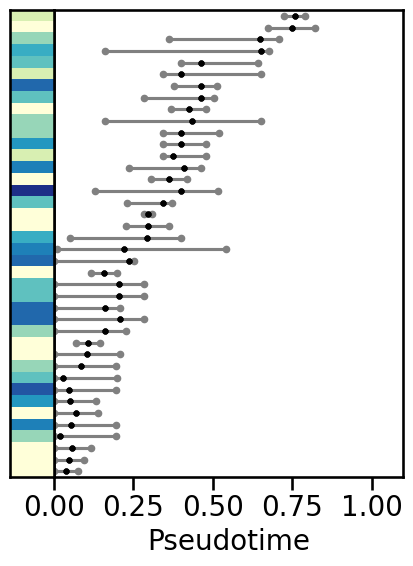

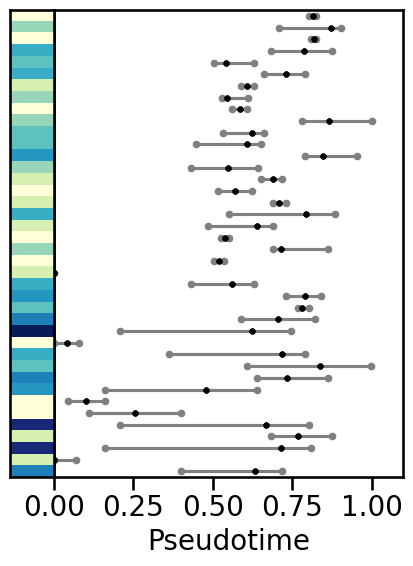

/tmp/ipykernel_1013018/3191914831.py:258: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


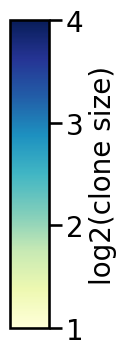

In [47]:
plot_clone_day_stats(clone_day_stats, clone_order, output_folder="./output", filename="S4E_eosinophils", plot_width=4, FONT_SIZE=20)

In [48]:
trajectory_cells_ad = cells_ad[trajectory_cells_df.index].copy()

trajectory_cells_df["sample_day_as_int"] = trajectory_cells_df["sample_day_rank"]
mc.ut.set_o_data(trajectory_cells_ad, "sample_day_as_int", trajectory_cells_df["sample_day_as_int"])

/tmp/ipykernel_1013018/3435372291.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trajectory_cells_df["sample_day_as_int"] = trajectory_cells_df["sample_day_rank"]


In [49]:
use_saved_data = True

In [50]:
if use_saved_data:
    synthetic_run_dfs = utils.load_pickle(os.path.join(data_path, "S4E_Eosinophils_synthetic_run_dfs.pkl"))
    synthetic_runs_cells_df = utils.load_pickle(os.path.join(data_path, "S4E_Eosinophils_synthetic_runs_cells_df.pkl"))

else:
    n_runs = 1000
    args_list = list(range(n_runs))
    
    ds_cells_df = mc.ut.get_vo_frame(trajectory_cells_with_clones_ad, "downsampled")

    wrapped_func = partial(
        run_single_synthetic,
        trajectory_cells_df=trajectory_cells_df,
        ds_cells_df=ds_cells_df,
        clone_day_stats=clone_day_stats,
        target_umis=target_umis,
        trajectory_genes_modules=trajectory_genes_modules,
        pc=pc,
    )

    # Parallel execution
    results = utils.run_multiprocess(wrapped_func, args_list, num_workers=100, thread_pool=False)
    synthetic_run_dfs = [result[0] for result in results]
    synthetic_runs_cells_df = [result[1] for result in results]

In [51]:
if not use_saved_data:
    utils.save_to_pickle(synthetic_run_dfs, os.path.join(data_path, "S4E_Eosinophils_synthetic_run_dfs.pkl"))
    utils.save_to_pickle(synthetic_runs_cells_df, os.path.join(data_path, "S4E_Eosinophils_synthetic_runs_cells_df.pkl"))

In [52]:
all_runs_df = pd.concat(synthetic_run_dfs)

# Median across runs per (clone, day)
synthetic_median_stats = (
    all_runs_df
    .groupby(["clone_exp_id", "sample_day_as_int"])
    .median()
    .reset_index()
)

/tmp/ipykernel_1013018/3191914831.py:194: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("YlGnBu")


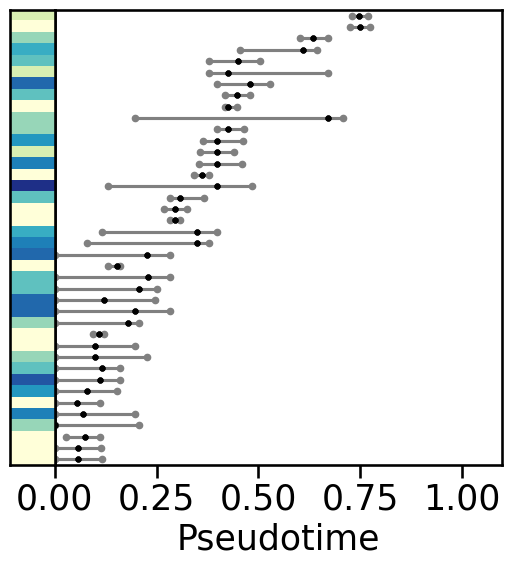

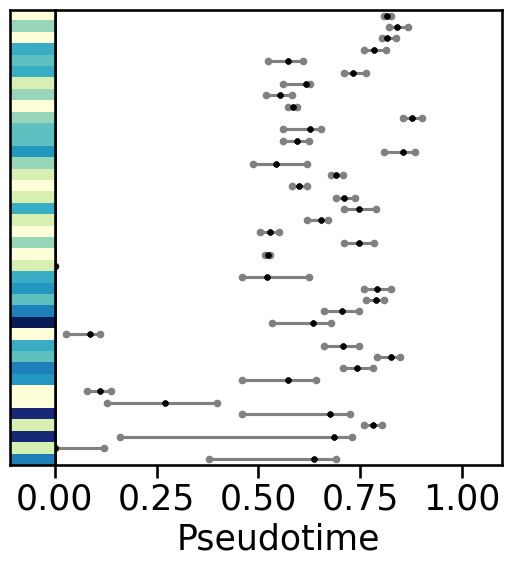

/tmp/ipykernel_1013018/3191914831.py:258: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


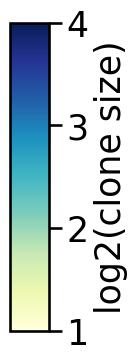

In [53]:
plot_clone_day_stats(synthetic_median_stats, clone_order)

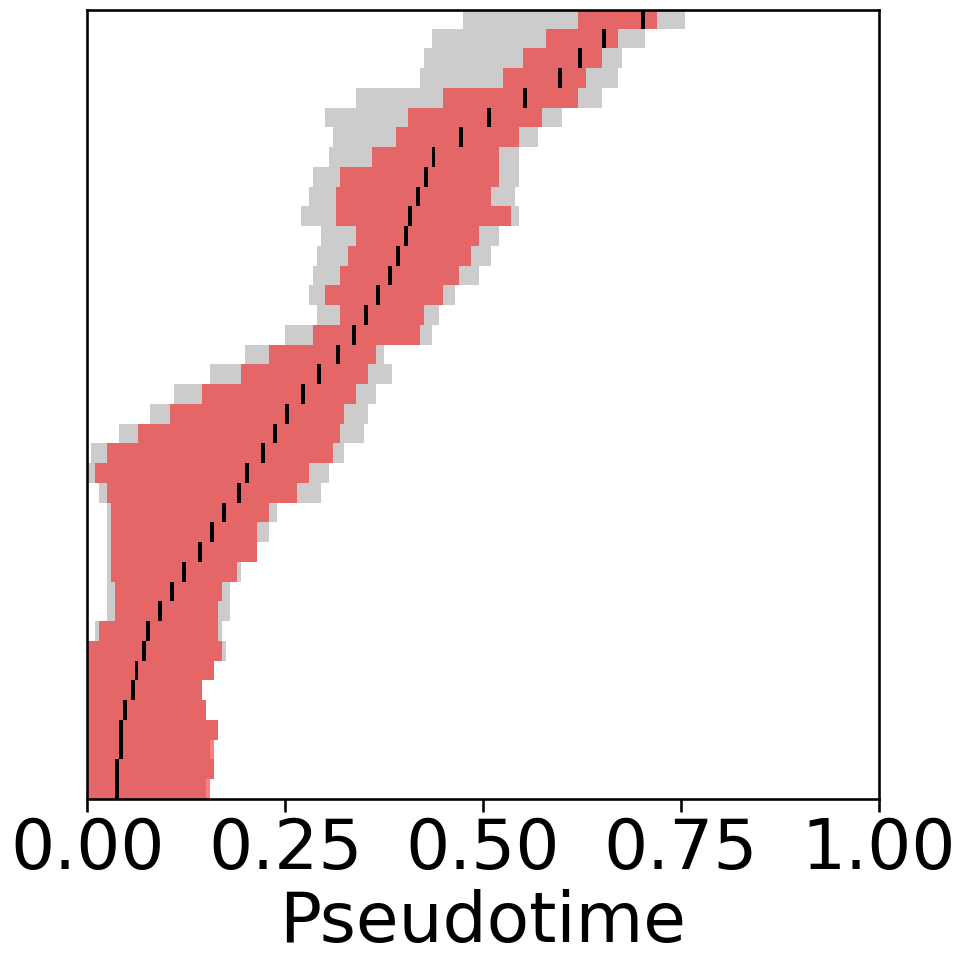

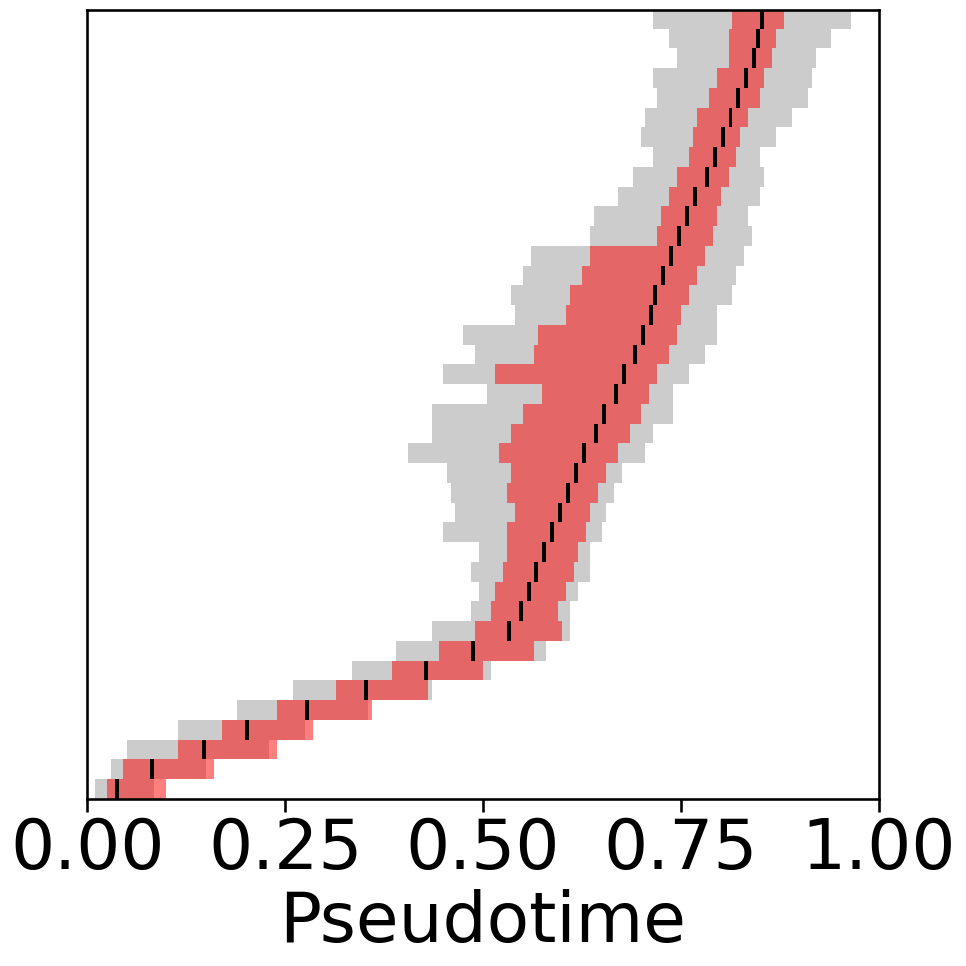

In [54]:
for day in clone_day_stats.sample_day_as_int.unique():
    pseudotime_df = clone_day_stats[clone_day_stats["sample_day_as_int"] == day].copy()
    clone_order = clone_day_stats[clone_day_stats["sample_day_as_int"] == day].sort_values("median_pseudotime").clone_exp_id.tolist()
    pseudotime_df.clone_exp_id = pd.Categorical(pseudotime_df.clone_exp_id, categories=clone_order, ordered=True)
    pseudotime_df = pseudotime_df.sort_values("clone_exp_id").reset_index(drop=True)
    synthetic_df = synthetic_median_stats[synthetic_median_stats.sample_day_as_int == day].copy()
    synthetic_df.clone_exp_id = pd.Categorical(synthetic_df.clone_exp_id, categories=clone_order, ordered=True)
    synthetic_df = synthetic_df.sort_values("clone_exp_id").reset_index(drop=True)
    plot_pseudotime_heatmap(pseudotime_df.sort_index(ascending=False), synthetic_df.sort_index(ascending=False), n_bins=200, 
                            figsize=(10, 10), row_window=7, red_alpha=0.5, fontsize=50, n_rows_multipler=0.01,
                            otuput_path="./output", filename=f"S4E_eosinophils_day{day}")


In [55]:
for day in clone_day_stats.sample_day_as_int.unique():
    kstet_res = ks_2samp(
            synthetic_median_stats[synthetic_median_stats.sample_day_as_int == day].delta_pseudotime,
            clone_day_stats[clone_day_stats.sample_day_as_int == day].delta_pseudotime
        )
    print(f"Day {day}: KS test statistic={kstet_res.statistic}, p-value={kstet_res.pvalue}")

Day 1: KS test statistic=0.275, p-value=0.09707484379785862
Day 2: KS test statistic=0.45, p-value=0.0005039436209702519


In [56]:
trajectory = "Basophils"
trajectory_genes_modules =  {i+"_score_sum": gene_modules_dict[i] for i in gene_modules_dict if "baso" in i}

trajectory_cells_with_clones_ad = mc.ut.slice(cells_with_clones, obs=cells_with_clones.obs.top_level_cell_type.isin(constants.TRAJECTORIES_TO_TOP_LEVEL_CELL_TYPE_DICT[trajectory]))

# filter only cells with at least two timepoints and at least 2 cells per timepoint
min_cells_per_timepoint = 2
min_timepoints = 2

n_cells_per_clone_per_day = trajectory_cells_with_clones_ad.obs.groupby(["clone_exp_id","sample_day_as_int"]).size().unstack().fillna(0).astype(int) 
clones_with_enough_data = n_cells_per_clone_per_day.index[np.sum(n_cells_per_clone_per_day >= min_cells_per_timepoint, axis=1) >= min_timepoints]
trajectory_cells_with_clones_ad = mc.ut.slice(trajectory_cells_with_clones_ad, obs=trajectory_cells_with_clones_ad.obs.clone_exp_id.isin(clones_with_enough_data))
trajectory_metacells_ad = mc.ut.slice(metacells_ad, obs=metacells_ad.obs.type.isin(constants.TRAJECTORIES_TO_TOP_LEVEL_CELL_TYPE_DICT[trajectory]))
mc.ut.set_o_data(trajectory_metacells_ad, "type", pd.Categorical(trajectory_metacells_ad.obs.type, categories=[i for i in cell_type_colors if i in trajectory_metacells_ad.obs.type.unique()], ordered=True))

mc.ut.set_o_data(trajectory_cells_with_clones_ad, "pseudotime", trajectory_cells_with_clones_ad.obs["%s_pseudotime" %trajectory].values)
trajectory_cells_with_clones_ad.obs.groupby(["condition"]).clone_exp_id.nunique().sort_values()

trajectory_metacells_ad = mc.ut.slice(metacells_ad, obs=metacells_ad.obs.type.isin(constants.TRAJECTORIES_TO_TOP_LEVEL_CELL_TYPE_DICT[trajectory]))
trajectory_cells = mc.ut.slice(cells_with_clones, obs=cells_with_clones.obs.cell_type.isin(constants.TRAJECTORIES_TO_TOP_LEVEL_CELL_TYPE_DICT[trajectory]))

pc = trajectory_pc_mapper[trajectory]

orig_trajectory_cells_with_clones_ad = trajectory_cells_with_clones_ad.copy()

/tmp/ipykernel_1013018/3791557561.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  n_cells_per_clone_per_day = trajectory_cells_with_clones_ad.obs.groupby(["clone_exp_id","sample_day_as_int"]).size().unstack().fillna(0).astype(int)
set unnamed.obs[type]: 244 objects
set unnamed.obs[pseudotime]: 3499 float64s
/tmp/ipykernel_1013018/3791557561.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trajectory_cells_with_clones_ad.obs.groupby(["condition"]).clone_exp_id.nunique().sort_values()


In [57]:
condition = "III"
trajectory_cells_with_clones_ad = mc.ut.slice(trajectory_cells_with_clones_ad, obs=trajectory_cells_with_clones_ad.obs.condition == condition)


mc.ut.set_o_data(trajectory_cells_with_clones_ad, "sample_day_rank", trajectory_cells_with_clones_ad.obs.groupby("exp_id")["sample_day_as_int"].rank(method="dense").astype(int))

exp_day = 2

n_cells_per_clone_per_day = trajectory_cells_with_clones_ad.obs.groupby(["clone_exp_id","sample_day_rank"]).size().unstack().fillna(0) 
n_cells_per_clone_per_day = n_cells_per_clone_per_day[n_cells_per_clone_per_day[3] ==0 ][[1,2]]
clones_with_enough_data = n_cells_per_clone_per_day.index[np.sum(n_cells_per_clone_per_day >= min_cells_per_timepoint, axis=1) == 2]
trajectory_cells_with_clones_ad = mc.ut.slice(trajectory_cells_with_clones_ad, obs=trajectory_cells_with_clones_ad.obs.clone_exp_id.isin(clones_with_enough_data))

/tmp/ipykernel_1013018/1483380274.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mc.ut.set_o_data(trajectory_cells_with_clones_ad, "sample_day_rank", trajectory_cells_with_clones_ad.obs.groupby("exp_id")["sample_day_as_int"].rank(method="dense").astype(int))
set unnamed.obs[sample_day_rank]: 1330 int64s
/tmp/ipykernel_1013018/1483380274.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  n_cells_per_clone_per_day = trajectory_cells_with_clones_ad.obs.groupby(["clone_exp_id","sample_day_rank"]).size().unstack().fillna(0)


In [58]:
trajectory_cells_df, clone_day_stats, clone_order = get_clones_stats_info(trajectory_cells_with_clones_ad)

# Recreate trajectory_cells_df
trajectory_cells_df = trajectory_cells_with_clones_ad.obs[["sample_day_rank", "clone_exp_id", "pseudotime"]]

# Grouped object
grouped = trajectory_cells_df.groupby(["clone_exp_id", "sample_day_rank"])

# Compute aggregated stats excluding MAD
clone_day_stats = (
    grouped
    .agg(
        n_cells=("pseudotime", "count"),
        mean_pseudotime=("pseudotime", "mean"),
        median_pseudotime=("pseudotime", "median"),
        max_pseudotime=("pseudotime", "max"),
        min_pseudotime=("pseudotime", "min"),
        std_pseudotime=("pseudotime", "std"),
    )
    .reset_index()
)

# Compute MAD separately and merge
mad_series = grouped["pseudotime"].apply(lambda x: np.mean(np.abs(x - x.mean()))).rename("mad_pseudotime")
clone_day_stats = clone_day_stats.merge(mad_series, on=["clone_exp_id", "sample_day_rank"])

clone_day_stats["sample_day_as_int"] = clone_day_stats["sample_day_rank"]

# Compute delta
clone_day_stats["delta_pseudotime"] = (
    clone_day_stats["max_pseudotime"] - clone_day_stats["min_pseudotime"]
)

# Get the first timepoint
first_day = clone_day_stats["sample_day_rank"].min()

# Subset just that day's stats
first_day_df = clone_day_stats[clone_day_stats["sample_day_rank"] == first_day].copy()

# Sort by min_pseudotime and delta
first_day_df = first_day_df.sort_values(
    by=["mean_pseudotime", "delta_pseudotime"],
    ascending=[True, False]
)

# Get clone order
clone_order = first_day_df["clone_exp_id"].tolist()

/tmp/ipykernel_1013018/3191914831.py:117: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trajectory_cells_df["pseudotime"] = trajectory_cells_df["pseudotime"].values
/tmp/ipykernel_1013018/3191914831.py:120: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = trajectory_cells_df.groupby(["clone_exp_id", "sample_day_as_int"])
/tmp/ipykernel_1013018/3229143171.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the

In [59]:
print(f"Number of clones: {len(clone_day_stats.clone_exp_id.unique())}")

Number of clones: 71


/tmp/ipykernel_1013018/3191914831.py:194: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("YlGnBu")


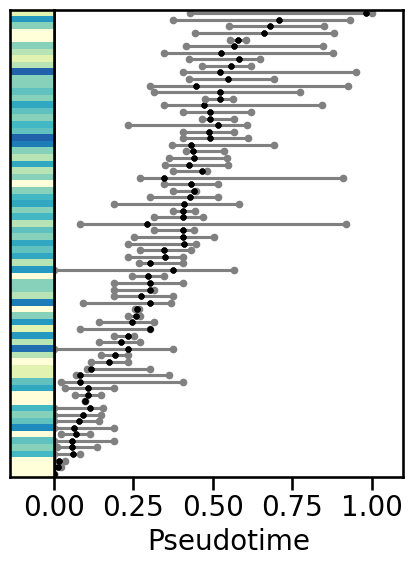

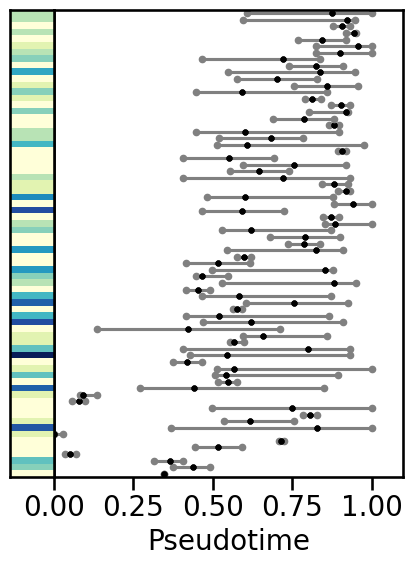

/tmp/ipykernel_1013018/3191914831.py:258: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


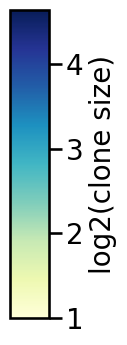

In [60]:
plot_clone_day_stats(clone_day_stats, clone_order, output_folder="./output", filename="S4E_basophils", plot_width=4, FONT_SIZE=20)

In [61]:
trajectory_cells_ad = cells_ad[trajectory_cells_df.index].copy()

trajectory_cells_df["sample_day_as_int"] = trajectory_cells_df["sample_day_rank"]
mc.ut.set_o_data(trajectory_cells_ad, "sample_day_as_int", trajectory_cells_df["sample_day_as_int"])

/tmp/ipykernel_1013018/3435372291.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trajectory_cells_df["sample_day_as_int"] = trajectory_cells_df["sample_day_rank"]


In [62]:
use_saved_data = True

In [63]:
if use_saved_data:
    synthetic_run_dfs = utils.load_pickle(os.path.join(data_path, "S4E_Basophils_synthetic_run_dfs.pkl"))
    synthetic_runs_cells_df = utils.load_pickle(os.path.join(data_path, "S4E_Basophils_synthetic_runs_cells_df.pkl"))

else:
    n_runs = 1000
    args_list = list(range(n_runs))
    
    ds_cells_df = mc.ut.get_vo_frame(trajectory_cells_with_clones_ad, "downsampled")

    wrapped_func = partial(
        run_single_synthetic,
        trajectory_cells_df=trajectory_cells_df,
        ds_cells_df=ds_cells_df,
        clone_day_stats=clone_day_stats,
        target_umis=target_umis,
        trajectory_genes_modules=trajectory_genes_modules,
        pc=pc,
    )

    # Parallel execution
    results = utils.run_multiprocess(wrapped_func, args_list, num_workers=100, thread_pool=False)
    synthetic_run_dfs = [result[0] for result in results]
    synthetic_runs_cells_df = [result[1] for result in results]

In [64]:
if not use_saved_data:
    utils.save_to_pickle(synthetic_run_dfs, os.path.join(data_path, "S4E_Basophils_synthetic_run_dfs.pkl"))
    utils.save_to_pickle(synthetic_runs_cells_df, os.path.join(data_path, "S4E_Basophils_synthetic_runs_cells_df.pkl"))

In [65]:
all_runs_df = pd.concat(synthetic_run_dfs)

# Median across runs per (clone, day)
synthetic_median_stats = (
    all_runs_df
    .groupby(["clone_exp_id", "sample_day_as_int"])
    .median()
    .reset_index()
)

/tmp/ipykernel_1013018/3191914831.py:194: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("YlGnBu")


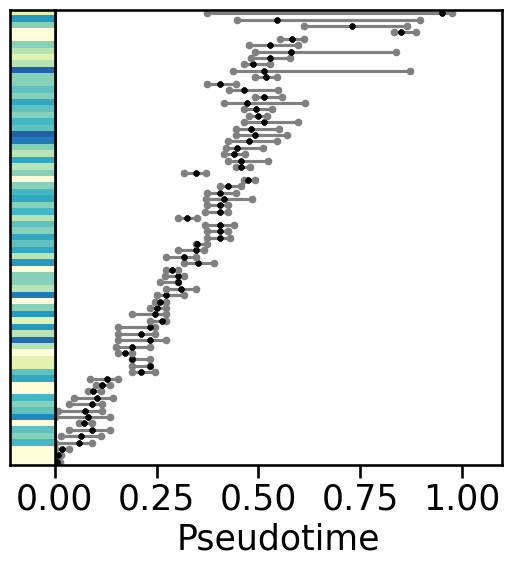

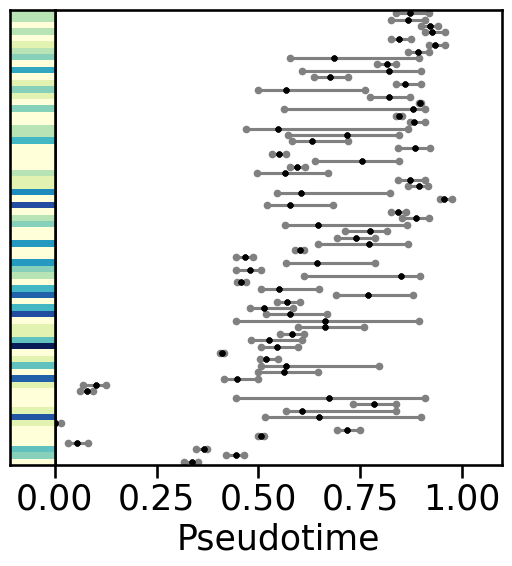

/tmp/ipykernel_1013018/3191914831.py:258: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


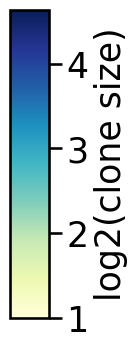

In [66]:
plot_clone_day_stats(synthetic_median_stats, clone_order)

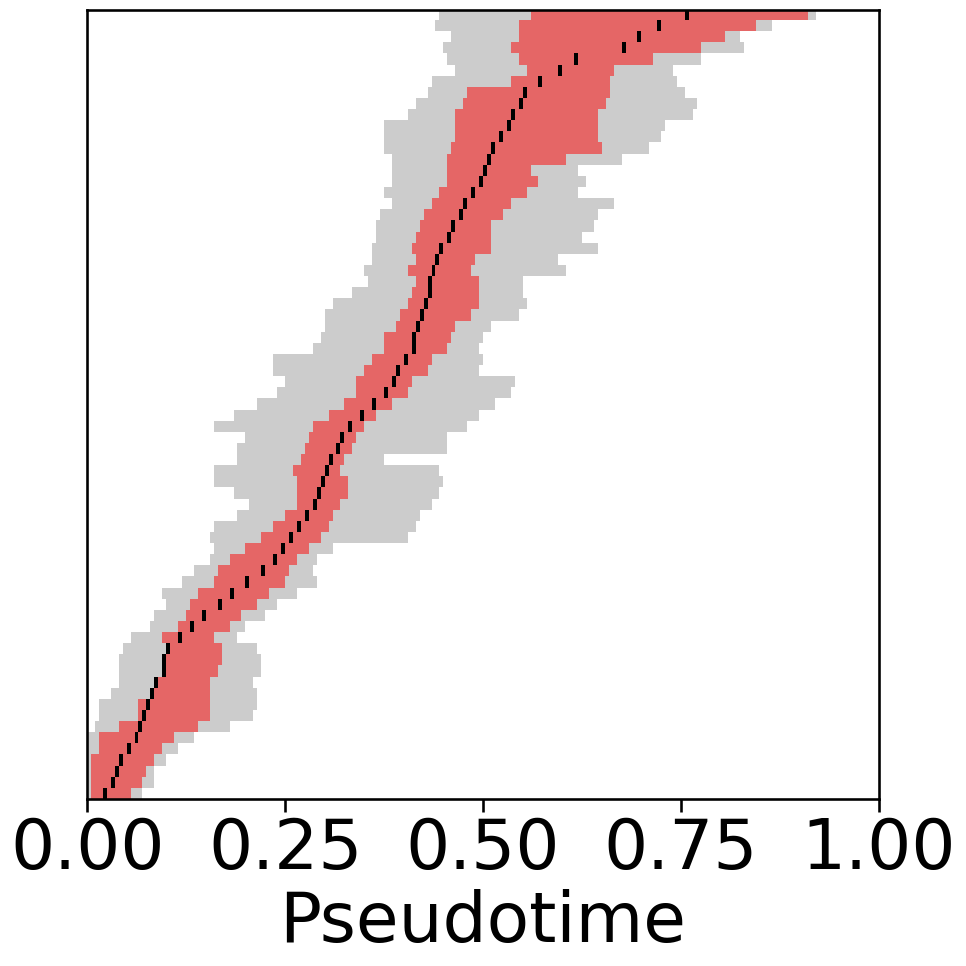

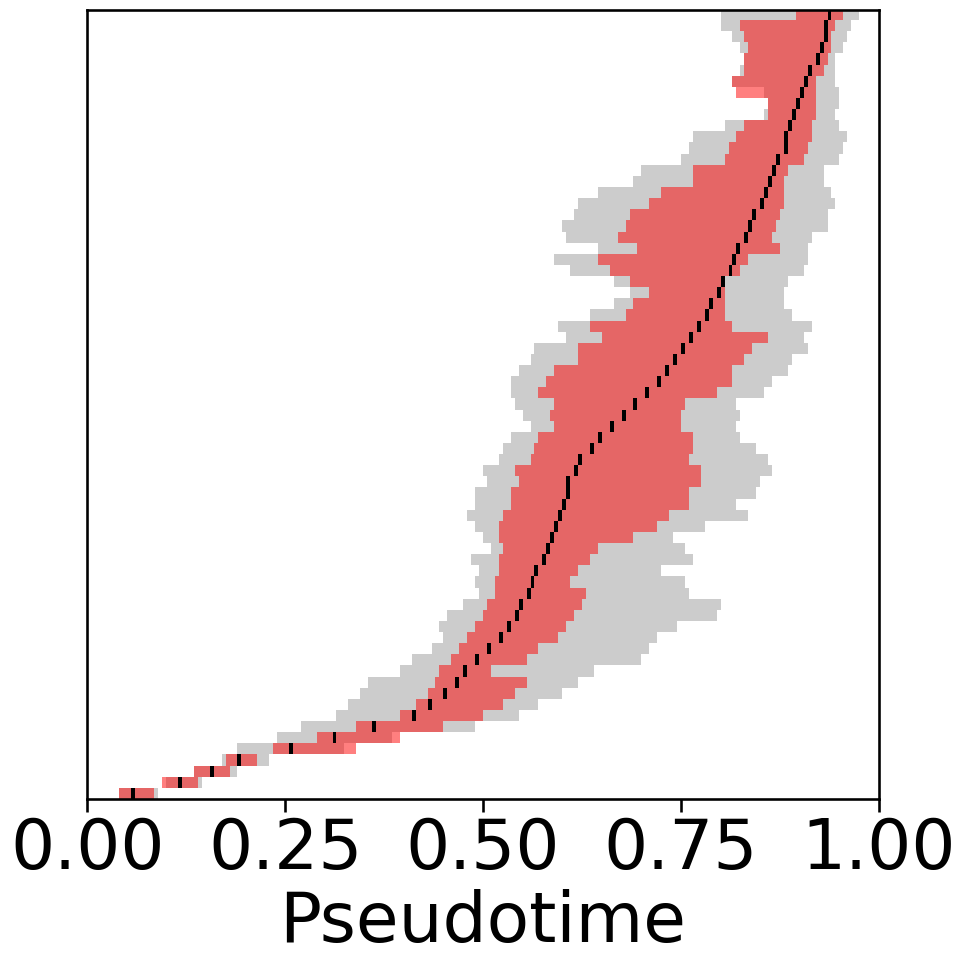

In [67]:
for day in clone_day_stats.sample_day_as_int.unique():
    pseudotime_df = clone_day_stats[clone_day_stats["sample_day_as_int"] == day].copy()
    clone_order = clone_day_stats[clone_day_stats["sample_day_as_int"] == day].sort_values("median_pseudotime").clone_exp_id.tolist()
    pseudotime_df.clone_exp_id = pd.Categorical(pseudotime_df.clone_exp_id, categories=clone_order, ordered=True)
    pseudotime_df = pseudotime_df.sort_values("clone_exp_id").reset_index(drop=True)
    synthetic_df = synthetic_median_stats[synthetic_median_stats.sample_day_as_int == day].copy()
    synthetic_df.clone_exp_id = pd.Categorical(synthetic_df.clone_exp_id, categories=clone_order, ordered=True)
    synthetic_df = synthetic_df.sort_values("clone_exp_id").reset_index(drop=True)
    plot_pseudotime_heatmap(pseudotime_df.sort_index(ascending=False), synthetic_df.sort_index(ascending=False), n_bins=200, 
                            figsize=(10, 10), row_window=7, red_alpha=0.5, fontsize=50, n_rows_multipler=0.01,
                            otuput_path="./output", filename=f"S4E_Basophils_day{day}")


In [68]:
for day in clone_day_stats.sample_day_as_int.unique():
    kstet_res = ks_2samp(
            synthetic_median_stats[synthetic_median_stats.sample_day_as_int == day].delta_pseudotime,
            clone_day_stats[clone_day_stats.sample_day_as_int == day].delta_pseudotime
        )
    print(f"Day {day}: KS test statistic={kstet_res.statistic}, p-value={kstet_res.pvalue}")

Day 1: KS test statistic=0.5915492957746479, p-value=7.332985976298289e-12
Day 2: KS test statistic=0.29577464788732394, p-value=0.00382399117622038


In [69]:
trajectory = "Mast"
trajectory_genes_modules =  {i+"_score_sum": gene_modules_dict[i] for i in gene_modules_dict if "mast" in i}

trajectory_cells_with_clones_ad = mc.ut.slice(cells_with_clones, obs=cells_with_clones.obs.top_level_cell_type.isin(constants.TRAJECTORIES_TO_TOP_LEVEL_CELL_TYPE_DICT[trajectory]))

# filter only cells with at least two timepoints and at least 2 cells per timepoint
min_cells_per_timepoint = 2
min_timepoints = 2

n_cells_per_clone_per_day = trajectory_cells_with_clones_ad.obs.groupby(["clone_exp_id","sample_day_as_int"]).size().unstack().fillna(0).astype(int) 
clones_with_enough_data = n_cells_per_clone_per_day.index[np.sum(n_cells_per_clone_per_day >= min_cells_per_timepoint, axis=1) >= min_timepoints]
trajectory_cells_with_clones_ad = mc.ut.slice(trajectory_cells_with_clones_ad, obs=trajectory_cells_with_clones_ad.obs.clone_exp_id.isin(clones_with_enough_data))
trajectory_metacells_ad = mc.ut.slice(metacells_ad, obs=metacells_ad.obs.type.isin(constants.TRAJECTORIES_TO_TOP_LEVEL_CELL_TYPE_DICT[trajectory]))
mc.ut.set_o_data(trajectory_metacells_ad, "type", pd.Categorical(trajectory_metacells_ad.obs.type, categories=[i for i in cell_type_colors if i in trajectory_metacells_ad.obs.type.unique()], ordered=True))

mc.ut.set_o_data(trajectory_cells_with_clones_ad, "pseudotime", trajectory_cells_with_clones_ad.obs["%s_pseudotime" %trajectory].values)
trajectory_cells_with_clones_ad.obs.groupby(["condition"]).clone_exp_id.nunique().sort_values()

trajectory_metacells_ad = mc.ut.slice(metacells_ad, obs=metacells_ad.obs.type.isin(constants.TRAJECTORIES_TO_TOP_LEVEL_CELL_TYPE_DICT[trajectory]))
trajectory_cells = mc.ut.slice(cells_with_clones, obs=cells_with_clones.obs.cell_type.isin(constants.TRAJECTORIES_TO_TOP_LEVEL_CELL_TYPE_DICT[trajectory]))

pc = trajectory_pc_mapper[trajectory]

orig_trajectory_cells_with_clones_ad = trajectory_cells_with_clones_ad.copy()

/tmp/ipykernel_1013018/3870260052.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  n_cells_per_clone_per_day = trajectory_cells_with_clones_ad.obs.groupby(["clone_exp_id","sample_day_as_int"]).size().unstack().fillna(0).astype(int)
set unnamed.obs[type]: 133 objects
set unnamed.obs[pseudotime]: 2096 float64s
/tmp/ipykernel_1013018/3870260052.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trajectory_cells_with_clones_ad.obs.groupby(["condition"]).clone_exp_id.nunique().sort_values()


In [70]:
condition = "III"
trajectory_cells_with_clones_ad = mc.ut.slice(trajectory_cells_with_clones_ad, obs=trajectory_cells_with_clones_ad.obs.condition == condition)


mc.ut.set_o_data(trajectory_cells_with_clones_ad, "sample_day_rank", trajectory_cells_with_clones_ad.obs.groupby("exp_id")["sample_day_as_int"].rank(method="dense").astype(int))

exp_day = 2

n_cells_per_clone_per_day = trajectory_cells_with_clones_ad.obs.groupby(["clone_exp_id","sample_day_rank"]).size().unstack().fillna(0) 
n_cells_per_clone_per_day = n_cells_per_clone_per_day[n_cells_per_clone_per_day[3] ==0 ][[1,2]]
clones_with_enough_data = n_cells_per_clone_per_day.index[np.sum(n_cells_per_clone_per_day >= min_cells_per_timepoint, axis=1) == 2]
trajectory_cells_with_clones_ad = mc.ut.slice(trajectory_cells_with_clones_ad, obs=trajectory_cells_with_clones_ad.obs.clone_exp_id.isin(clones_with_enough_data))

/tmp/ipykernel_1013018/1483380274.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mc.ut.set_o_data(trajectory_cells_with_clones_ad, "sample_day_rank", trajectory_cells_with_clones_ad.obs.groupby("exp_id")["sample_day_as_int"].rank(method="dense").astype(int))
set unnamed.obs[sample_day_rank]: 1012 int64s
/tmp/ipykernel_1013018/1483380274.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  n_cells_per_clone_per_day = trajectory_cells_with_clones_ad.obs.groupby(["clone_exp_id","sample_day_rank"]).size().unstack().fillna(0)


In [71]:
trajectory_cells_df, clone_day_stats, clone_order = get_clones_stats_info(trajectory_cells_with_clones_ad)

# Recreate trajectory_cells_df
trajectory_cells_df = trajectory_cells_with_clones_ad.obs[["sample_day_rank", "clone_exp_id", "pseudotime"]]

# Grouped object
grouped = trajectory_cells_df.groupby(["clone_exp_id", "sample_day_rank"])

# Compute aggregated stats excluding MAD
clone_day_stats = (
    grouped
    .agg(
        n_cells=("pseudotime", "count"),
        mean_pseudotime=("pseudotime", "mean"),
        median_pseudotime=("pseudotime", "median"),
        max_pseudotime=("pseudotime", "max"),
        min_pseudotime=("pseudotime", "min"),
        std_pseudotime=("pseudotime", "std"),
    )
    .reset_index()
)

# Compute MAD separately and merge
mad_series = grouped["pseudotime"].apply(lambda x: np.mean(np.abs(x - x.mean()))).rename("mad_pseudotime")
clone_day_stats = clone_day_stats.merge(mad_series, on=["clone_exp_id", "sample_day_rank"])

clone_day_stats["sample_day_as_int"] = clone_day_stats["sample_day_rank"]

# Compute delta
clone_day_stats["delta_pseudotime"] = (
    clone_day_stats["max_pseudotime"] - clone_day_stats["min_pseudotime"]
)

# Get the first timepoint
first_day = clone_day_stats["sample_day_rank"].min()

# Subset just that day's stats
first_day_df = clone_day_stats[clone_day_stats["sample_day_rank"] == first_day].copy()

# Sort by min_pseudotime and delta
first_day_df = first_day_df.sort_values(
    by=["mean_pseudotime", "delta_pseudotime"],
    ascending=[True, False]
)

# Get clone order
clone_order = first_day_df["clone_exp_id"].tolist()

/tmp/ipykernel_1013018/3191914831.py:117: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trajectory_cells_df["pseudotime"] = trajectory_cells_df["pseudotime"].values
/tmp/ipykernel_1013018/3191914831.py:120: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = trajectory_cells_df.groupby(["clone_exp_id", "sample_day_as_int"])
/tmp/ipykernel_1013018/3229143171.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the

In [72]:
print(f"Number of clones: {len(clone_day_stats.clone_exp_id.unique())}")

Number of clones: 56


/tmp/ipykernel_1013018/3191914831.py:194: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("YlGnBu")


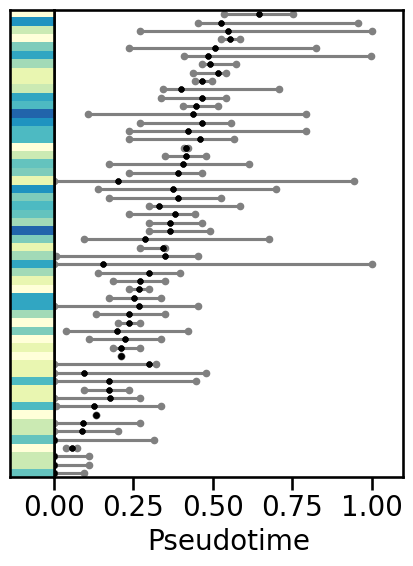

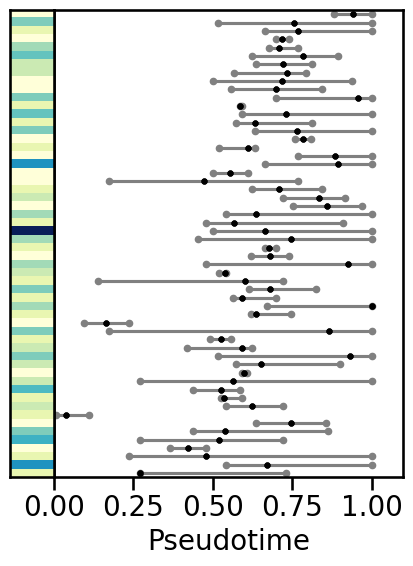

/tmp/ipykernel_1013018/3191914831.py:258: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


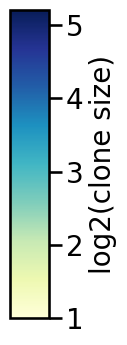

In [73]:
plot_clone_day_stats(clone_day_stats, clone_order, output_folder="./output", filename="S4E_mast", plot_width=4, FONT_SIZE=20)

In [74]:
trajectory_cells_ad = cells_ad[trajectory_cells_df.index].copy()

trajectory_cells_df["sample_day_as_int"] = trajectory_cells_df["sample_day_rank"]
mc.ut.set_o_data(trajectory_cells_ad, "sample_day_as_int", trajectory_cells_df["sample_day_as_int"])

/tmp/ipykernel_1013018/3435372291.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trajectory_cells_df["sample_day_as_int"] = trajectory_cells_df["sample_day_rank"]


In [75]:
use_saved_data = True

In [76]:
if use_saved_data:
    synthetic_run_dfs = utils.load_pickle(os.path.join(data_path, "S4E_Mast_synthetic_run_dfs.pkl"))
    synthetic_runs_cells_df = utils.load_pickle(os.path.join(data_path, "S4E_Mast_synthetic_runs_cells_df.pkl"))

else:
    n_runs = 1000
    args_list = list(range(n_runs))
    
    ds_cells_df = mc.ut.get_vo_frame(trajectory_cells_with_clones_ad, "downsampled")

    wrapped_func = partial(
        run_single_synthetic,
        trajectory_cells_df=trajectory_cells_df,
        ds_cells_df=ds_cells_df,
        clone_day_stats=clone_day_stats,
        target_umis=target_umis,
        trajectory_genes_modules=trajectory_genes_modules,
        pc=pc,
    )

    # Parallel execution
    results = utils.run_multiprocess(wrapped_func, args_list, num_workers=100, thread_pool=False)
    synthetic_run_dfs = [result[0] for result in results]
    synthetic_runs_cells_df = [result[1] for result in results]

In [77]:
if not use_saved_data:
    utils.save_to_pickle(synthetic_run_dfs, os.path.join(data_path, "S4E_Mast_synthetic_run_dfs.pkl"))
    utils.save_to_pickle(synthetic_runs_cells_df, os.path.join(data_path, "S4E_Mast_synthetic_runs_cells_df.pkl"))

In [78]:
all_runs_df = pd.concat(synthetic_run_dfs)

# Median across runs per (clone, day)
synthetic_median_stats = (
    all_runs_df
    .groupby(["clone_exp_id", "sample_day_as_int"])
    .median()
    .reset_index()
)

/tmp/ipykernel_1013018/3191914831.py:194: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("YlGnBu")


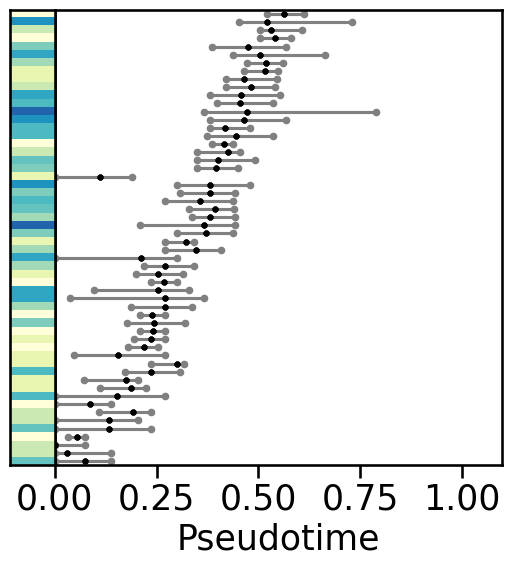

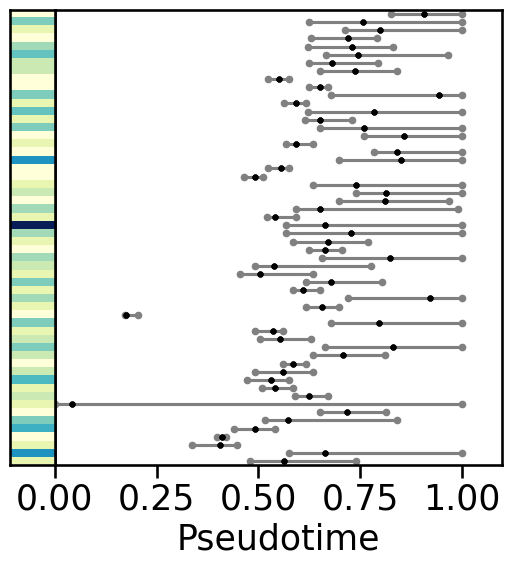

/tmp/ipykernel_1013018/3191914831.py:258: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


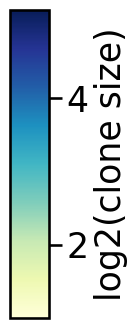

In [79]:
plot_clone_day_stats(synthetic_median_stats, clone_order)

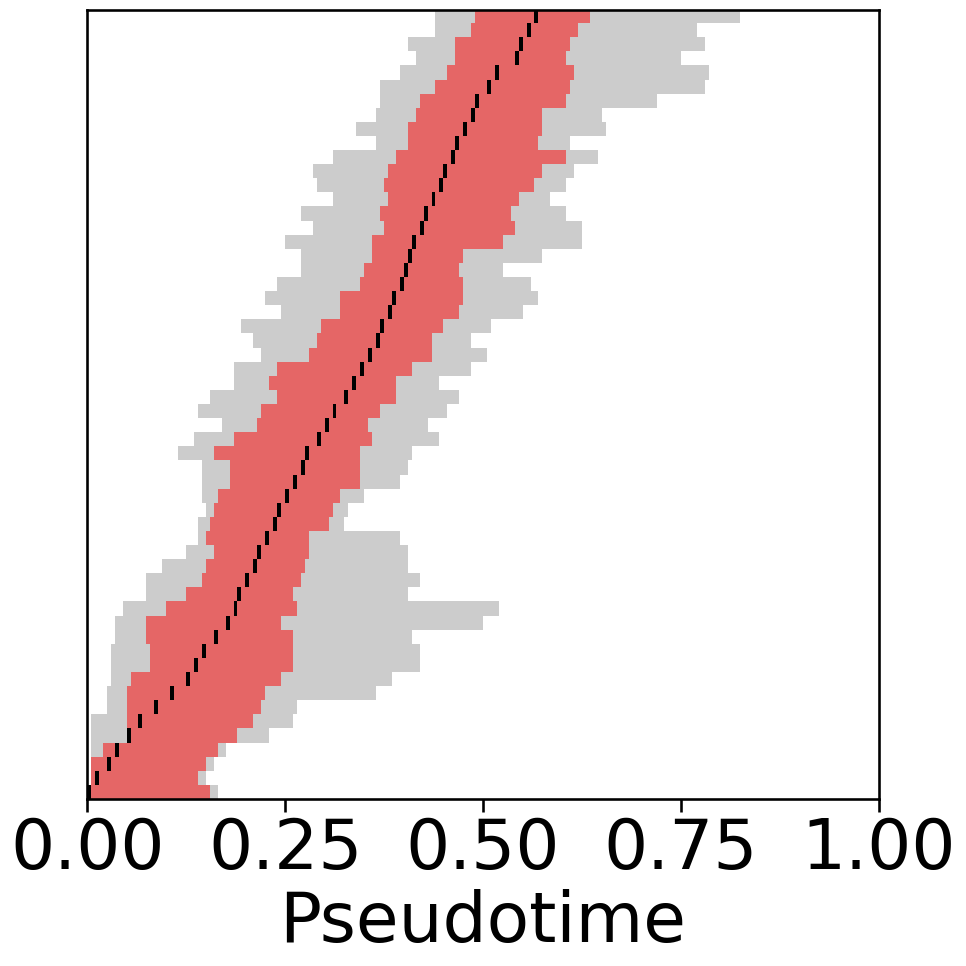

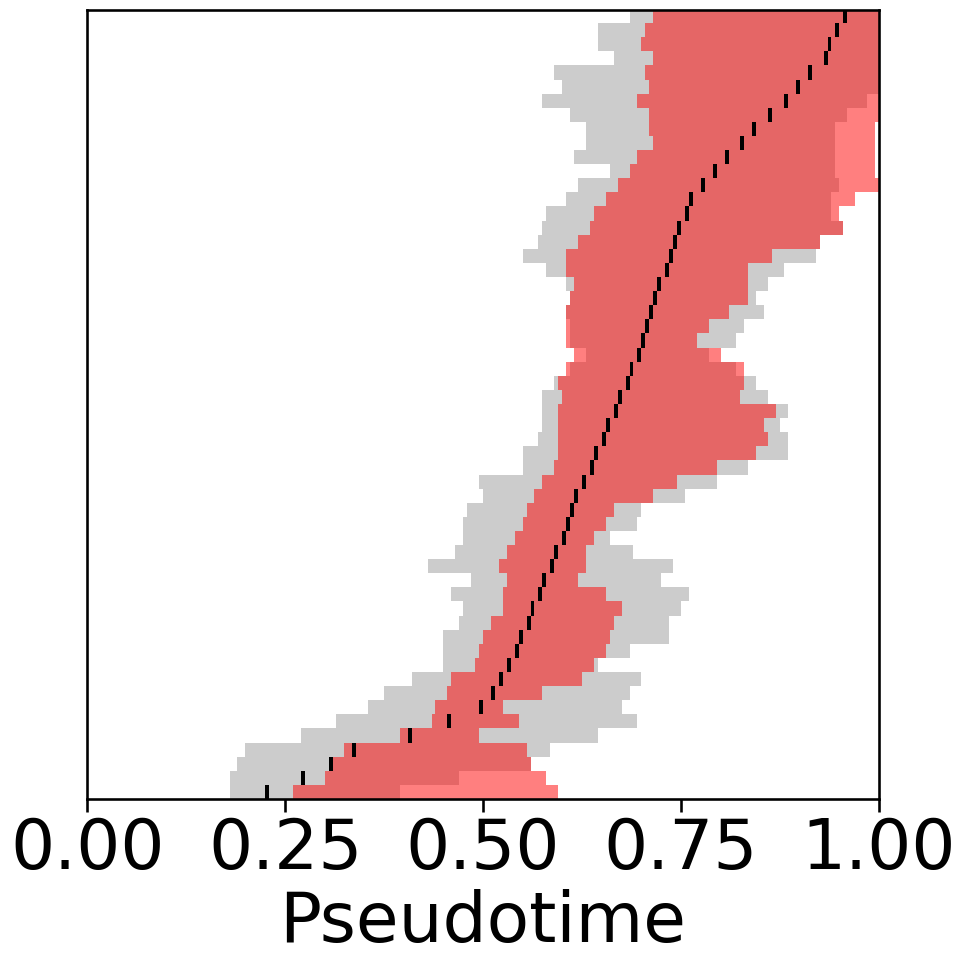

In [80]:
for day in clone_day_stats.sample_day_as_int.unique():
    pseudotime_df = clone_day_stats[clone_day_stats["sample_day_as_int"] == day].copy()
    clone_order = clone_day_stats[clone_day_stats["sample_day_as_int"] == day].sort_values("median_pseudotime").clone_exp_id.tolist()
    pseudotime_df.clone_exp_id = pd.Categorical(pseudotime_df.clone_exp_id, categories=clone_order, ordered=True)
    pseudotime_df = pseudotime_df.sort_values("clone_exp_id").reset_index(drop=True)
    synthetic_df = synthetic_median_stats[synthetic_median_stats.sample_day_as_int == day].copy()
    synthetic_df.clone_exp_id = pd.Categorical(synthetic_df.clone_exp_id, categories=clone_order, ordered=True)
    synthetic_df = synthetic_df.sort_values("clone_exp_id").reset_index(drop=True)
    plot_pseudotime_heatmap(pseudotime_df.sort_index(ascending=False), synthetic_df.sort_index(ascending=False), n_bins=200, 
                            figsize=(10, 10), row_window=7, red_alpha=0.5, fontsize=50, n_rows_multipler=0.01,
                            otuput_path="./output", filename=f"S4E_eosinophils_day{day}")


In [81]:
for day in clone_day_stats.sample_day_as_int.unique():
    kstet_res = ks_2samp(
            synthetic_median_stats[synthetic_median_stats.sample_day_as_int == day].delta_pseudotime,
            clone_day_stats[clone_day_stats.sample_day_as_int == day].delta_pseudotime
        )
    print(f"Day {day}: KS test statistic={kstet_res.statistic}, p-value={kstet_res.pvalue}")

Day 1: KS test statistic=0.39285714285714285, p-value=0.0003024072673017951
Day 2: KS test statistic=0.26785714285714285, p-value=0.035536438323688906
